### О задании

В данном задании необходимо реализовать обучение линейной регрессии с помощью различных вариантов градиентного спуска.

Баллы даются за выполнение отдельных пунктов (Максимальное количество баллов за эту Л.Р. - 5)

Задачи в рамках одного раздела рекомендуется решать в том порядке, в котором они даны в задании.

Неэффективная реализация кода может негативно отразиться на оценке.
Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.


### Формат сдачи
Задания сдаются через lms. Вы прикрепляете **ССЫЛКУ НА ПУБЛИЧНЫЙ РЕПОЗИТОРИЙ**, где выполнено ваше задание.


Приготовьтесь, потому что на лекциях и семинарах мы уже прошли через джунгли теории, оттачивая наши навыки в мастерстве оптимизации функционалов. Мы погружались в глубины градиентного спуска, изучая его в каждом возможном амплуа — от классического полного градиента до беспощадного стохастического градиента, не забывая про метод с импульсом, который как боксерский удар прорывается сквозь проблемы оптимизации.

Теперь же перед вами стоит вызов, который не для слабонервных. Ваша миссия, если вы, конечно, осмелитесь ее принять, — взять в арсенал четыре разнообразных вида градиентного спуска и смастерить из них инструмент, способный расправиться с любой задачей. Вам предстоит создать собственную версию линейной регрессии, такую, что даже самые опытные аналитики данных будут смотреть на нее с завистью. Испытайте на реальных данных весь арсенал вашего градиентного спуска, сравните, какой из них выходит на арену оптимизации как несокрушимый чемпион.

Это задание не для тех, кто привык стоять в сторонке. Это ваш момент славы, ваш шанс выйти на арену, где вашим оружием будет код, а противниками — самые коварные задачи машинного обучения. Покажите, на что вы способны, и пусть ваш код станет легендой!

@GPT-4

## Задание 1. Реализация градиентного спуска (1.75 балла)

В этом задании вам предстоит написать собственные реализации различных подходов к градиентному спуску с опорой на подготовленные шаблоны в файле `descents.py`.

**Все реализуемые методы должны быть векторизованы!**

### Лирическое размышление № 1

Ключевая характеристика антиградиента заключается в том, что он направлен к самому быстрому уменьшению значения функции в конкретной точке. Исходя из этого, разумным подходом будет начать движение с определенной точки, переместиться в направлении антиградиента, затем вновь вычислить антиградиент, совершить движение и продолжать таким образом. Давайте опишем этот процесс более формализованно.

Предположим, что $w_0$ – это исходный набор параметров (к примеру, набор из нулей или полученный из какого-либо случайного распределения). В этом случае простой градиентный спуск предполагает выполнение следующих действий до достижения сходимости:

$$
    w_{k + 1} = w_{k} - \eta_{k} \nabla_{w} Q(w_{k}).
$$

### Лирическое размышление № 2

### Задание 0.0. Градиент MSE в матричном виде (0 баллов).

Напомним, что функция потерь MSE записывается в матричном виде как:

Давайте найдем градиент функции $Q(w)$ по $w$, используя матричное дифференцирование. Функция $Q(w)$ определена как:

$$
Q(w) = \frac{1}{\ell} (y - Xw)^T (y - Xw)
$$

где:
- $Q(w)$ — функция потерь,
- $\ell$ — количество наблюдений


- $y$ — вектор истинных значений,
- $X$ — матрица признаков,
- $w$ — вектор весов.

Градиент функции потерь $Q(w)$ по $w$ находится следующим образом:

1. Раскроем скобки в выражении для $Q(w)$:
   
$$
Q(w) = \frac{1}{\ell} (y^Ty - y^TXw - w^TX^Ty + w^TX^TXw)
$$

2. Заметим, что $y^TXw$ и $w^TX^Ty$ представляют собой скаляры и равны между собой. Тогда выражение упрощается до:
   
$$
Q(w) = \frac{1}{\ell} (y^Ty - 2y^TXw + w^TX^TXw)
$$

3. Теперь дифференцируем $Q(w)$ по $w$. При дифференцировании $y^Ty$ как константа относительно $w$ исчезает, а дифференциация оставшейся части дает:

$$
\nabla_w Q(w) = \frac{1}{\ell} (-2X^Ty + 2X^TXw)
$$

4. Упростим выражение, вынеся 2 за скобки:

$$
\nabla_w Q(w) = \frac{2}{\ell} (X^TXw - X^Ty)
$$

Таким образом, градиент функции потерь $Q(w)$ по вектору весов $w$ равен:

$$
\nabla_w Q(w) = \frac{2}{\ell} (X^TXw - X^Ty)
$$

Это выражение и есть искомый градиент.

### Задание 1.1. Родительский класс BaseDescent (0.25 балла).

Реализуйте функции `calc_loss` (вычисление MSE для переданных $x$ и $y$) и `predict` (предсказание $y_{pred}$ для переданных $x$) в классе `BaseDescent`.

Все вычисления должны быть векторизованы.

In [1]:
from dataclasses import dataclass
from enum import auto
from enum import Enum
from typing import Dict
from typing import Type
import numpy as np
from descents import LearningRate, LossFunction

class BaseDescent:
    def __init__(self, dimension: int, lambda_: float = 1e-3, loss_function: LossFunction = LossFunction.MSE):
        self.w: np.ndarray = np.random.rand(dimension)
        self.lr: LearningRate = LearningRate(lambda_=lambda_)
        self.loss_function: LossFunction = loss_function


    def step(self, x: np.ndarray, y: np.ndarray) -> np.ndarray:
        return self.update_weights(self.calc_gradient(x, y))

    def update_weights(self, gradient: np.ndarray) -> np.ndarray:
        pass

    def calc_gradient(self, x: np.ndarray, y: np.ndarray) -> np.ndarray:
        pass

    def calc_loss(self, x: np.ndarray, y: np.ndarray) -> float:
        y_pred = self.predict(x)
        return np.mean((y_pred - y) ** 2)

    def predict(self, x: np.ndarray) -> np.ndarray:
        return x @ self.w

### Задание 1.2. Полный градиентный спуск VanillaGradientDescent (0.25 балла).

Реализуйте полный градиентный спуск заполнив пропуски в классе `VanillaGradientDescent` в файле `descents.py`. Для вычисления градиента используйте формулу выше. Шаг оптимизации:

$$
    w_{k + 1} = w_{k} - \eta_{k} \nabla_{w} Q(w_{k}).
$$

Здесь и далее функция `update_weights` должна возвращать разницу между $w_{k + 1}$ и $w_{k}$: $\quad w_{k + 1} - w_{k} = -\eta_{k} \nabla_{w} Q(w_{k})$.

Во всех методах градиентного спуска мы будем использовать следующую формулу для длины шага:

$$
    \eta_{k} = \lambda \left(\dfrac{s_0}{s_0 + k}\right)^p
$$

На практике достаточно настроить параметр $\lambda$, а остальным выставить параметры по умолчанию: $s_0 = 1, \, p = 0.5.$

In [2]:
class VanillaGradientDescent(BaseDescent):
    def update_weights(self, gradient: np.ndarray) -> np.ndarray:
        learning_rate = self.lr()  # Получаем текущую скорость обучения η_k
        delta_w = -learning_rate * gradient  # Вычисляем шаг: -η_k * ∇Q(w_k)
        self.w += delta_w  # Обновляем веса
        return delta_w  # Возвращаем разницу между новыми и старыми весами

    def calc_gradient(self, x: np.ndarray, y: np.ndarray) -> np.ndarray:
        n_samples = y.shape[0]
        y_pred = x @ self.w  # Предсказания: X @ w
        error = y_pred - y  # Ошибка: (Xw - y)
        gradient = (2 / n_samples) * x.T @ error  # Градиент MSE: (2/n) * X^T @ (Xw - y)
        return gradient

### Лирическое размышление № 3

Конечно, давайте переформулируем и перепишем ваш текст для лучшего понимания.

В контексте задач машинного обучения, обычно функционал ошибки $Q(w)$ можно представить как среднее арифметическое отдельных ошибок на каждом элементе выборки:

$$
    Q(w) = \frac{1}{\ell} \sum_{i = 1}^{\ell} q_i(w),
$$

где каждая функция $q_i(w)$ отражает ошибку на i-ом объекте выборки.

Основная сложность применения метода градиентного спуска заключается в необходимости вычисления градиента по всей выборке на каждом шаге. Это может быть особенно затруднительно при работе с большими данными. Однако, для эффективного шага в направлении минимизации функции потерь, абсолютная точность градиента может быть не столь критична.

Мы можем приблизить градиент всей функции, используя среднее значение градиентов для случайно выбранной подвыборки объектов:

$$
    \nabla_{w} Q(w_{k}) \approx \dfrac{1}{|B|} \sum_{i \in B} \nabla_{w} q_{i}(w_{k}),
$$

где $B$ является подмножеством выборки с случайно выбранными индексами.

Этот подход приводит нас к методу **стохастического градиентного спуска**, который значительно упрощает вычисления и ускоряет процесс обучения, особенно на больших данных.

### Задание 1.3. Стохастический градиентный спуск StochasticDescent (0.25 балла).

Реализуйте стохастический градиентный спуск заполнив пропуски в классе `StochasticDescent`. Для оценки градиента используйте формулу выше (среднее градиентов случайно выбранного батча объектов). Шаг оптимизации:

$$
    w_{k + 1} = w_{k} - \eta_{k} \dfrac{1}{|B|}\sum\limits_{i \in B}\nabla_{w} q_{i}(w_{k}).
$$

Размер батча будет являться гиперпараметром метода, семплируйте индексы для батча объектов с помощью `np.random.randint`.

In [3]:
class StochasticDescent(VanillaGradientDescent):

    def __init__(self, dimension: int, lambda_: float = 1e-3, batch_size: int = 50,
                 loss_function: LossFunction = LossFunction.MSE):
        super().__init__(dimension, lambda_, loss_function)
        self.batch_size = batch_size

    def calc_gradient(self, x: np.ndarray, y: np.ndarray) -> np.ndarray:

        # Случайный выбор индексов для батча
        indices = np.random.randint(0, len(y), size=self.batch_size)
        x_batch = x[indices]
        y_batch = y[indices]

        # Вычисление градиента для батча
        y_pred = x_batch @ self.w  # Предсказания для батча
        error = y_pred - y_batch   # Ошибка для батча
        gradient = (2 / self.batch_size) * x_batch.T @ error  # Усредненный градиент

        return gradient

### Лирическое размышление № 4

В процессе оптимизации может случиться так, что направление наискорейшего спуска, определенное антиградиентом, будет резко колебаться от одного шага к другому. Это часто происходит, если функция потерь имеет вытянутые уровни, что приводит к тому, что градиент, всегда перпендикулярный этим линиям, меняет свое направление на противоположное при каждом шаге. Эти колебания могут серьезно замедлить сходимость оптимизационного процесса из-за постоянных "колебаний" в обратных направлениях. Чтобы сгладить эти осцилляции и ускорить процесс оптимизации, применяется метод усреднения градиентов из нескольких предыдущих шагов, тем самым снижая "шум" и выявляя общее предпочтительное направление движения. Это достигается с помощью введения вектора инерции:

\begin{align}
    &h_0 = 0, \\
    &h_{k + 1} = \alpha h_{k} + \eta_k \nabla_w Q(w_{k}),
\end{align}

где $\alpha$ — коэффициент, контролирующий влияние градиентов предыдущих шагов, уменьшая их вклад со временем. Можно использовать аппроксимацию градиента для вычисления $h_{k + 1}$. Для осуществления следующего шага градиентного спуска текущую точку смещают на вектор инерции:

$$
    w_{k + 1} = w_{k} - h_{k + 1}.
$$

Такой подход позволяет сгладить колебания градиента: если градиент по какому-то направлению часто меняет знак, его вклад в вектор инерции будет уменьшаться, в то время как постоянное направление градиента приведет к увеличению шага в этом направлении, делая процесс оптимизации более стабильным и направленным.

### Задание 1.4 Метод Momentum MomentumDescent (0.25 балла).

Реализуйте градиентный спуск с методом инерции заполнив пропуски в классе `MomentumDescent`. Шаг оптимизации:

\begin{align}
    &h_0 = 0, \\
    &h_{k + 1} = \alpha h_{k} + \eta_k \nabla_w Q(w_{k}) \\
    &w_{k + 1} = w_{k} - h_{k + 1}.
\end{align}

$\alpha$ будет являться гиперпараметром метода, но в данном домашнем задании мы зафиксируем её за вас $\alpha = 0.9$.

In [4]:
class MomentumDescent(VanillaGradientDescent):

    def __init__(self, dimension: int, lambda_: float = 1e-3, loss_function: LossFunction = LossFunction.MSE):
        super().__init__(dimension, lambda_, loss_function)
        self.alpha: float = 0.9

        self.h: np.ndarray = np.zeros(dimension)

    def update_weights(self, gradient: np.ndarray) -> np.ndarray:
        learning_rate = self.lr()  # Получаем текущую скорость обучения η_k
        self.h = self.alpha * self.h + learning_rate * gradient  # h_{k+1} = αh_k + η_k ∇Q
        delta_w = -self.h  # Δw = -h_{k+1}
        self.w += delta_w  # Обновляем веса
        return delta_w

### Лирическо размышление № 5

Выбор размера шага играет критическую роль в эффективности градиентного спуска. Слишком большой шаг может привести к тому, что процесс будет "перепрыгивать" минимальное значение, а слишком маленький шаг существенно замедлит достижение минимума, требуя большего количества итераций. Предварительно определить идеальный размер шага невозможно, и даже стратегии постепенного его уменьшения могут оказаться неэффективными.

AdaGrad предлагает индивидуальный подход к регулированию длины шага для каждой отдельной компоненты параметров. Суть метода заключается в уменьшении размера шага в зависимости от общей длины предыдущих шагов по данному параметру:

\begin{align}
    &G_{kj} = G_{k-1,j} + (\nabla_w Q(w_{k - 1}))_j^2; \\
    &w_{jk} = w_{j,k-1} - \frac{\eta_t}{\sqrt{G_{kj}} + \varepsilon} (\nabla_w Q(w_{k - 1}))_j.
\end{align}

Где $\varepsilon$ — малая добавка для предотвращения деления на ноль.

В AdaGrad размер шага может быть фиксирован с самого начала, исключая необходимость его подбора в процессе. Этот метод особенно эффективен в задачах с разреженными данными, где большинство признаков для объектов равны нулю. Таким образом, большие шаги будут совершаться по редко встречающимся признакам, в то время как по часто встречающимся — маленькие.

Основной недостаток AdaGrad заключается в неизбежном замедлении шагов из-за монотонного роста $G_{kj}$, что может остановить процесс до достижения оптимального решения. Эту проблему решает метод RMSprop, где применяется экспоненциальное сглаживание для градиентов:

$$
    G_{kj} = \alpha G_{k-1,j} + (1 - \alpha) (\nabla_w Q(w^{(k-1)}))_j^2.
$$

Здесь шаг адаптируется в зависимости от интенсивности движения по каждому направлению на недавних итерациях.

Объединяя идеи этих методов, можно достичь эффективного накопления информации о градиентах для стабилизации процесса и внедрить адаптивную длину шага для каждого параметра, обеспечивая более сбалансированное и быстрое приближение к минимуму.

### Задание 1.5. Метод Adam (Adaptive Moment Estimation) (0.75 балла).

Реализуйте градиентный спуск с методом Adam заполнив пропуски в классе `Adam`. Шаг оптимизации:

\begin{align}
    &m_0 = 0, \quad v_0 = 0; \\ \\
    &m_{k + 1} = \beta_1 m_k + (1 - \beta_1) \nabla_w Q(w_{k}); \\ \\
    &v_{k + 1} = \beta_2 v_k + (1 - \beta_2) \left(\nabla_w Q(w_{k})\right)^2; \\ \\
    &\widehat{m}_{k} = \dfrac{m_k}{1 - \beta_1^{k}}, \quad \widehat{v}_{k} = \dfrac{v_k}{1 - \beta_2^{k}}; \\ \\
    &w_{k + 1} = w_{k} - \dfrac{\eta_k}{\sqrt{\widehat{v}_{k + 1}} + \varepsilon} \widehat{m}_{k + 1}.
\end{align}

$\beta_1 = 0.9, \beta_2 = 0.999$ и $\varepsilon = 10^{-8}$ будут зафиксированы за вас.

In [5]:
class Adam(VanillaGradientDescent):
    def __init__(self, dimension: int, lambda_: float = 1e-3, loss_function: LossFunction = LossFunction.MSE):

        super().__init__(dimension, lambda_, loss_function)
        self.eps: float = 1e-8

        self.m: np.ndarray = np.zeros(dimension)
        self.v: np.ndarray = np.zeros(dimension)

        self.beta_1: float = 0.9
        self.beta_2: float = 0.999

        self.iteration: int = 0

    def update_weights(self, gradient: np.ndarray) -> np.ndarray:

        self.iteration += 1

        # Обновляем моменты
        self.m = self.beta_1 * self.m + (1 - self.beta_1) * gradient
        self.v = self.beta_2 * self.v + (1 - self.beta_2) * (gradient ** 2)

        # Вычисляем моменты
        m_hat = self.m / (1 - self.beta_1 ** self.iteration)
        v_hat = self.v / (1 - self.beta_2 ** self.iteration)

        step = -self.lr() * m_hat / (np.sqrt(v_hat) + self.eps)
        self.w += step

        return step

## Задание 2. Реализация линейной регресии (0.25 балла)

Ваша задача — создать собственную версию линейной регрессии, которая будет обучаться с помощью метода градиентного спуска, следуя предоставленным шаблонам в файле `linear_regression.py` под классом **LinearRegression**. Главные требования к реализации:

- Используйте векторизацию для всех вычислений, минимизируйте использование циклов в Python, за исключением итераций градиентного спуска.
- Прекращайте обучение, когда выполнено хотя бы одно из следующих условий:
  - Евклидова норма разности векторов весов между двумя последовательными итерациями становится меньше заданного порога `tolerance`.
  - В векторе весов появляются значения NaN.
  - Достигнуто максимальное количество итераций `max_iter`.
- Предполагается, что данные для обучения уже содержат столбец из единиц в качестве последнего столбца, обеспечивающего вектор свободных членов.
- Для отслеживания процесса сходимости используйте массив `loss_history`, куда следует записывать значения функции потерь до начала первого шага градиентного спуска и после каждой итерации, включая итоговое значение после завершения обучения.

In [6]:
from __future__ import annotations

from typing import List

import numpy as np

from descents import BaseDescent
from descents import get_descent


class LinearRegression:
    def __init__(self, descent_config: dict, tolerance: float = 1e-4, max_iter: int = 300):

        self.descent: BaseDescent = get_descent(descent_config)

        self.tolerance: float = tolerance
        self.max_iter: int = max_iter

        self.loss_history: List[float] = []

    def fit(self, x: np.ndarray, y: np.ndarray) -> LinearRegression:

        self.loss_history.append(self.descent.calc_loss(x, y))

        for _ in range(self.max_iter):
            weight_update = self.descent.step(x, y)
            self.loss_history.append(self.descent.calc_loss(x, y))

            if np.linalg.norm(weight_update) < self.tolerance:
                break
            if np.isnan(self.descent.w).any():
                break

        return self

    def predict(self, x: np.ndarray) -> np.ndarray:
        return self.descent.predict(x)

    def calc_loss(self, x: np.ndarray, y: np.ndarray) -> float:
        return self.descent.calc_loss(x, y)

## Задание 3. Проверка кода (0 баллов)

In [7]:
%load_ext autoreload

In [8]:
%autoreload 2

import numpy as np

from descents import get_descent
from linear_regression import LinearRegression

In [9]:
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

In [10]:

descent_config = {
    'descent_name': 'типа что-то делает',
    'kwargs': {
        'dimension': dimension
    }
}

for descent_name in ['full', 'stochastic', 'momentum', 'adam']:
    descent_config['descent_name'] = descent_name
    descent = get_descent(descent_config)

    diff = descent.step(x, y)
    gradient = descent.calc_gradient(x, y)
    predictions = descent.predict(x)

    assert gradient.shape[0] == dimension, f'Gradient failed for descent {descent_name}'
    assert diff.shape[0] == dimension, f'Weights failed for descent {descent_name}'
    assert predictions.shape == y.shape, f'Prediction failed for descent {descent_name}'

In [11]:
# LinearRegression

max_iter = 10
tolerance = 0

descent_config = {
    'descent_name': 'stochastic',
    'kwargs': {
        'dimension': dimension,
        'batch_size': 10
    }
}

regression = LinearRegression(
    descent_config=descent_config,
    tolerance=tolerance,
    max_iter=max_iter
)

regression.fit(x, y)

assert len(regression.loss_history) == max_iter + 1, 'Loss history failed'

## Задание 4. Работа с данными (0.5 балла)

Мы будем использовать датасет объявлений по продаже машин на немецком Ebay. В задаче предсказания целевой переменной для нас будет являться цена.

Вам нужно выполнить базовый EDA анализ:

1. **Визуализация распределения целевой переменной**:
    - Постройте график распределения целевой переменной, чтобы оценить его форму.
    - Если распределение сильно скошено, рассмотрите возможность применения логарифмического преобразования к целевой переменной для нормализации распределения.
    - Оцените наличие выбросов, аномально высоких или низких значений целевой переменной, используя графический метод или статистические меры (например, интерквартильный размах).

2. **Удаление выбросов**:
    - Если в данных присутствуют выбросы с аномальной ценой, удалите их, чтобы они не искажали результаты анализа и моделирования.

3. **Исследование данных**:
    - Проанализируйте типы данных в столбцах (категориальные, числовые, текстовые и т.д.).
    - Постройте графики для анализа зависимости целевой переменной от других признаков. Это поможет понять, какие признаки влияют на целевую переменную.
    - Изучите распределения значений признаков для выявления аномалий и выбросов. Определите, какие признаки требуют предварительной обработки или трансформации.
    - На основе графиков и анализа определите, какие признаки кажутся полезными для моделирования.

4. **Предобработка данных**:
    - Определите, какие трансформации данных (например, нормализация, стандартизация, кодирование категориальных переменных) могут быть применены к признакам.
    - Разделите признаки на категории: категориальные, числовые (вещественные) и те, которые не требуют предобработки.

5. **Разделение данных на выборки**:
    - Разделите ваши данные на обучающую, валидационную и тестовую выборки в пропорции 8:1:1. Это важный шаг для оценки производительности модели и избежания переобучения.



In [12]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns



sns.set(style='darkgrid')

In [13]:
data = pd.read_csv('autos.csv')

In [14]:
data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


Колонки в данных:

* `brand` - название бренда автомобиля
* `model` - название модели автомобиля
* `vehicleType` - тип транспортного средства
* `gearbox` - тип трансмисcии
* `fuelType` - какой вид топлива использует автомобиль
* `notRepairedDamage` - есть ли в автомобиле неисправность, которая еще не устранена
* `powerPS` - мощность автомобиля в PS (метрическая лошадиная сила)
* `kilometer` - сколько километров проехал автомобиль, пробег
* `autoAgeMonths` - возраст автомобиля в месяцах


* `price` - цена, указанная в объявлении о продаже автомобиля (целевая переменная)

In [15]:
print(data.shape, data.isna().sum().sum())

(241190, 10) 0


Пропуски отсутствуют, отличный датасет

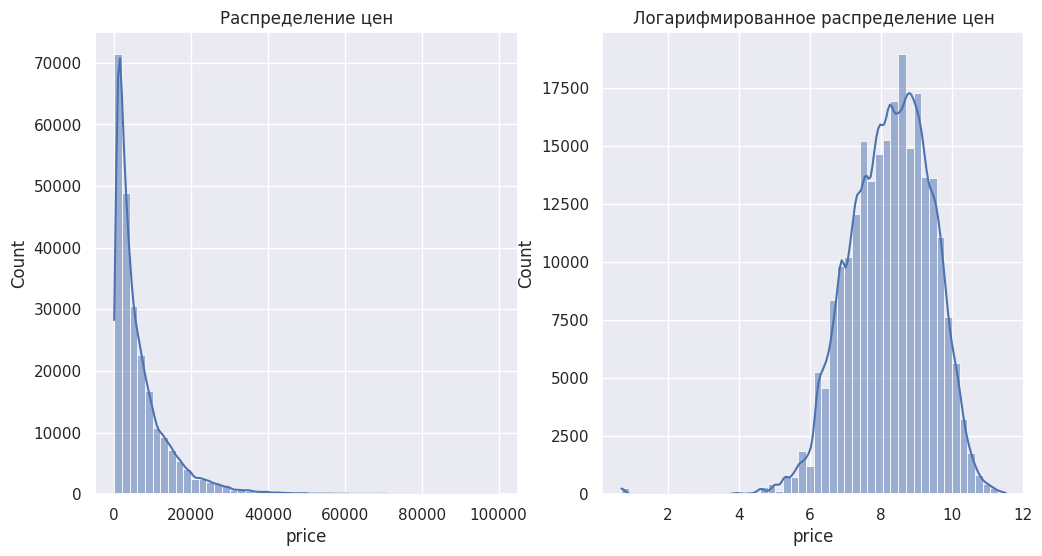

In [16]:
# Визуализация распределения целевой переменной (price)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(data['price'], bins=50, kde=True)
plt.title('Распределение цен')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(data['price']), bins=50, kde=True)
plt.title('Логарифмированное распределение цен')
plt.show()

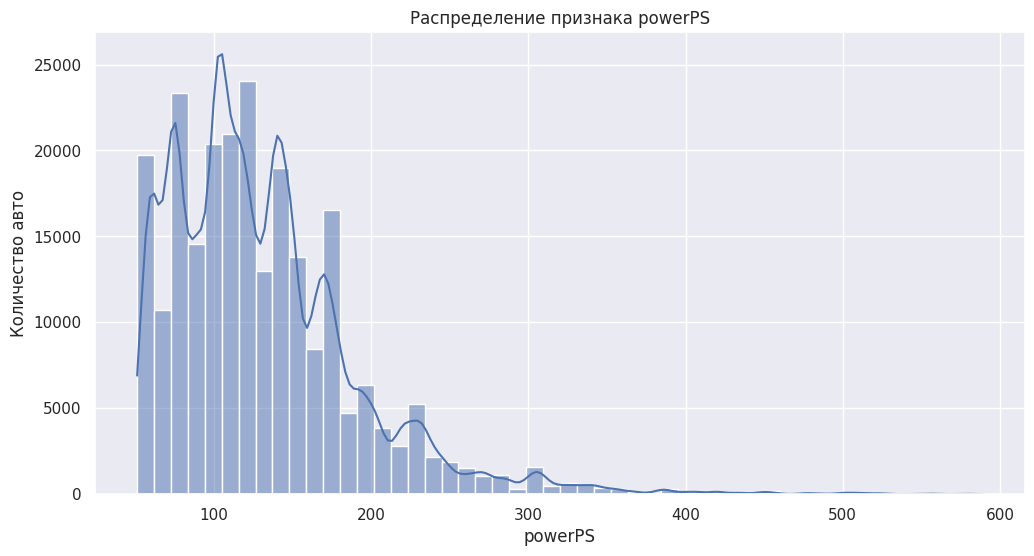

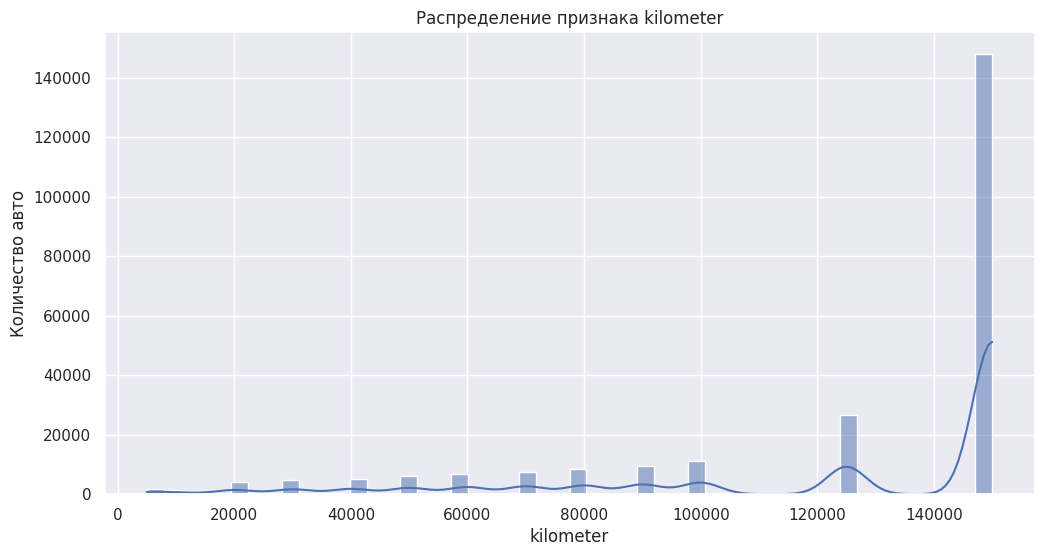

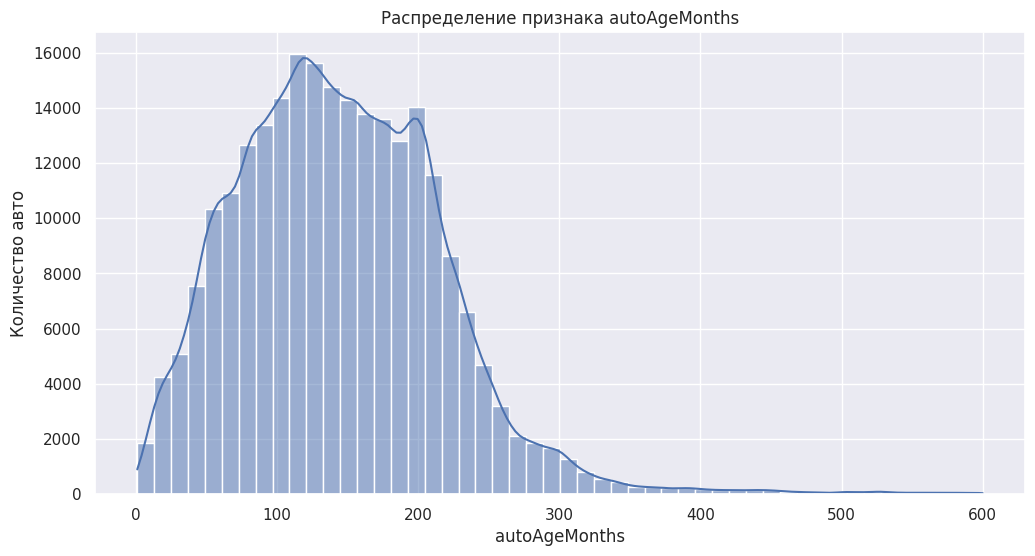

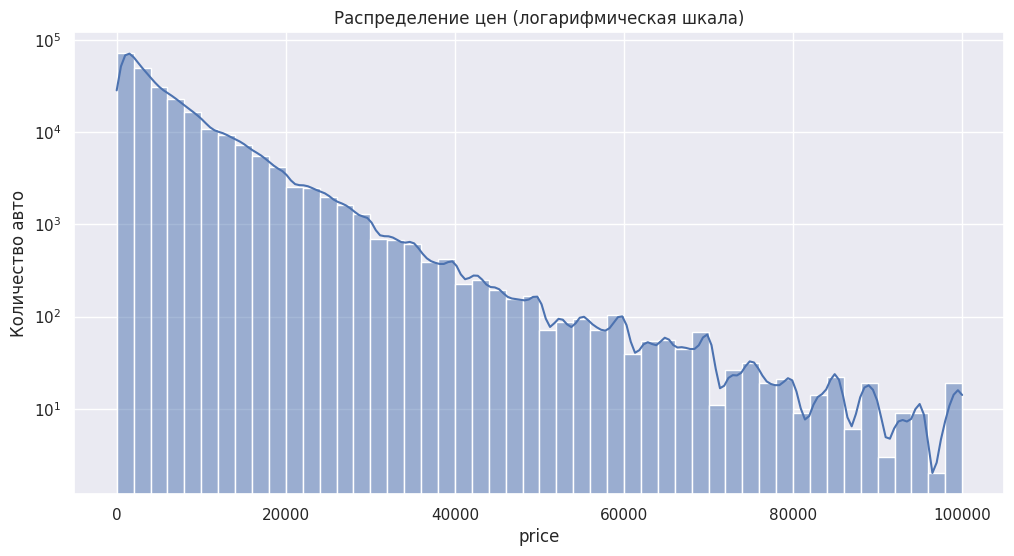

In [17]:
# Построим гистограммы для всех числовых признаков

num_features = ['powerPS', 'kilometer', 'autoAgeMonths', 'price']

for feature in num_features:
    plt.figure(figsize=(12, 6))
    sns.histplot(data=data, x=feature, bins=50, kde=True)

    if feature == 'price':
        plt.yscale('log')  # Логарифмическая шкала для цены
        plt.title(f'Распределение цен (логарифмическая шкала)')
    else:
        plt.title(f'Распределение признака {feature}')

    plt.xlabel(feature)
    plt.ylabel('Количество авто')
    plt.show()

Распределение мощности похоже на  экспоненциально убывающее распределение; пробег имеет правостороннее распределение, здесь аномалии это машины с низким пробегом . Возраст авто похож на нормальное распределение с  редкими выбросами. Распределение цены похоже на логнормальное

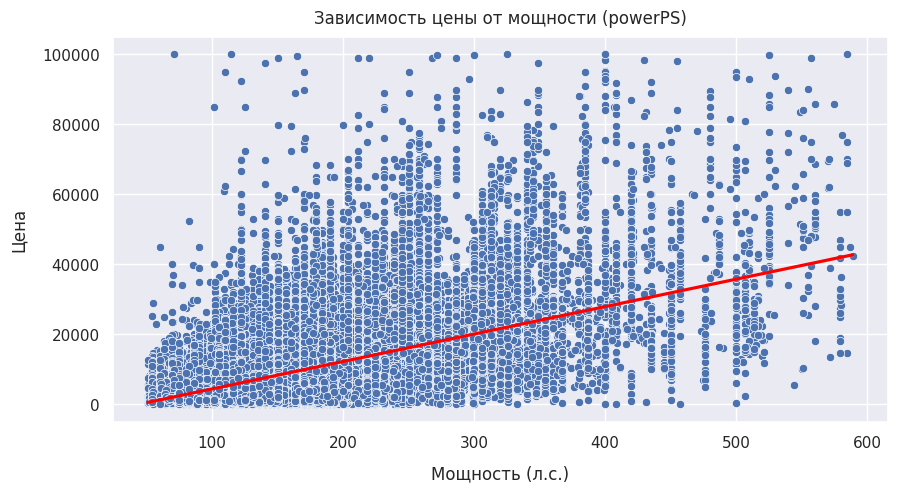

In [18]:
# Зависимость цены от мощности авто
plt.figure(figsize=(10, 5))

sns.scatterplot(data=data, x='powerPS', y='price')
sns.regplot(data=data, x='powerPS', y='price', scatter=False, color='red') # Добавление линии тренда

plt.title('Зависимость цены от мощности (powerPS)', pad=10)
plt.xlabel('Мощность (л.с.)', labelpad=10)
plt.ylabel('Цена', labelpad=10)
plt.show()

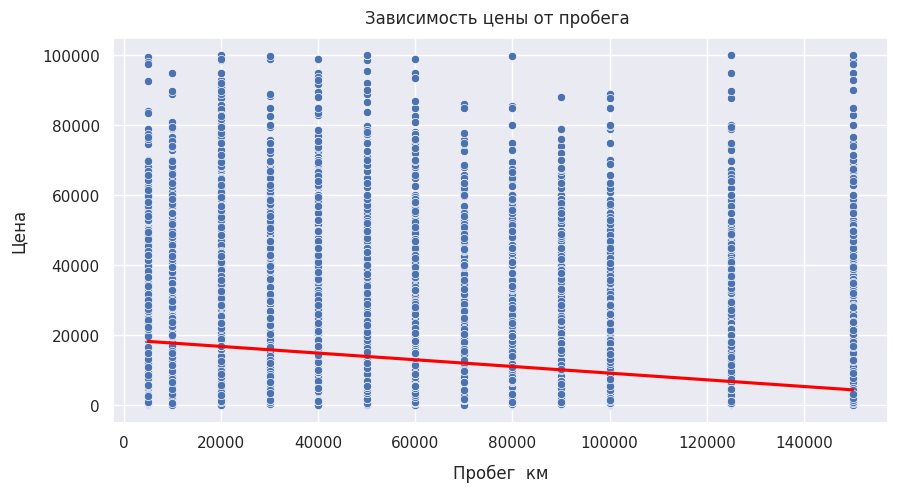

In [19]:
# Зависимость цены от пробега авто
plt.figure(figsize=(10, 5))

sns.scatterplot(data=data, x='kilometer', y='price')
sns.regplot(data=data, x='kilometer', y='price', scatter=False, color='red')

plt.title('Зависимость цены от пробега ', pad=10)
plt.xlabel('Пробег  км', labelpad=10)
plt.ylabel('Цена', labelpad=10)
plt.show()

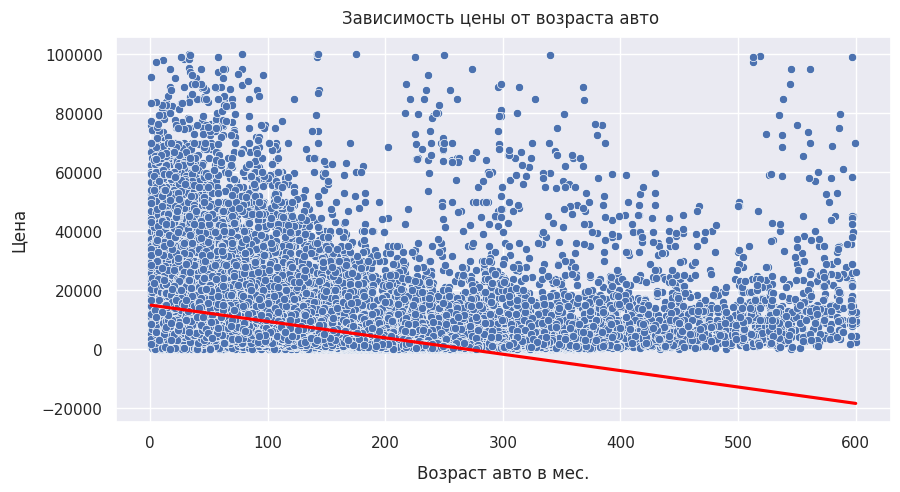

In [20]:
# Зависимость цены от возраста авто
plt.figure(figsize=(10, 5))

sns.scatterplot(data=data, x='autoAgeMonths', y='price')
sns.regplot(data=data, x='autoAgeMonths', y='price', scatter=False, color='red')

plt.title('Зависимость цены от возраста авто ', pad=10)
plt.xlabel('Возраст авто в мес.', labelpad=10)
plt.ylabel('Цена', labelpad=10)
plt.show()

Чем выше мощность автомобиля, тем выше цена и тем меньше таких автомобилей на рынке.
Чем больше пробег автомобиля и возраст, тем ниже его  цена,  Мощные и дорогие авто — аномалии, требующие обработки

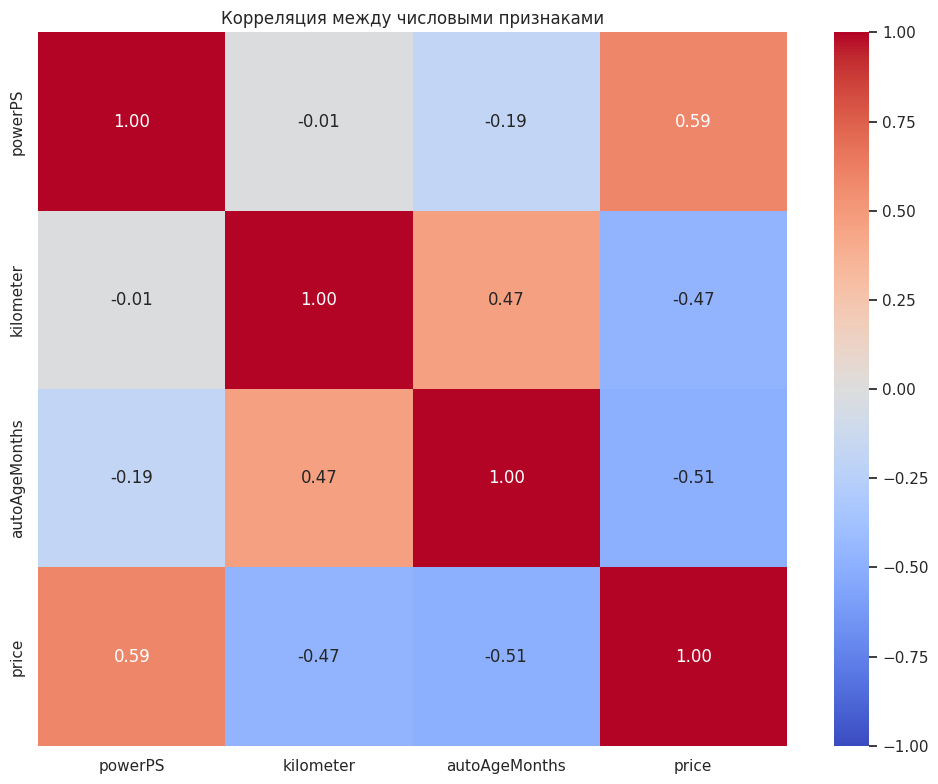

In [21]:
num_features = data[['powerPS', 'kilometer', 'autoAgeMonths', 'price']]
correlation = num_features.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1, vmax=1
)

plt.title('Корреляция между числовыми признаками')
plt.tight_layout()
plt.show()

Корреляция цены и мощности положительна: более мощные авто дороже. Для пар цена-пробег и цена-возраст авто  обратная зависимость: высокий пробег и возраст снижает цену

<ipython-input-22-36367a6e2175>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=feature, y=price, palette="viridis"  )


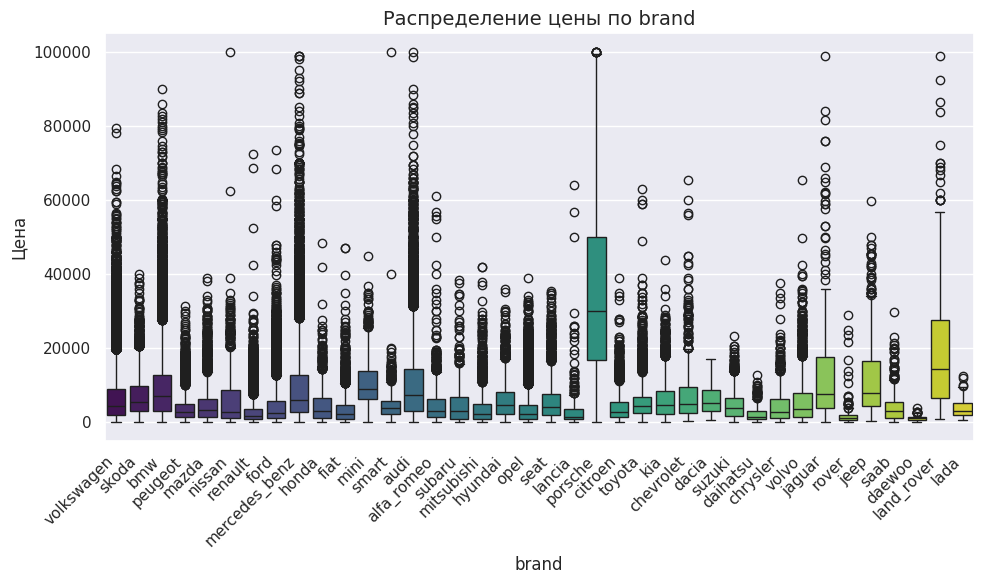

<ipython-input-22-36367a6e2175>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=feature, y=price, palette="viridis"  )


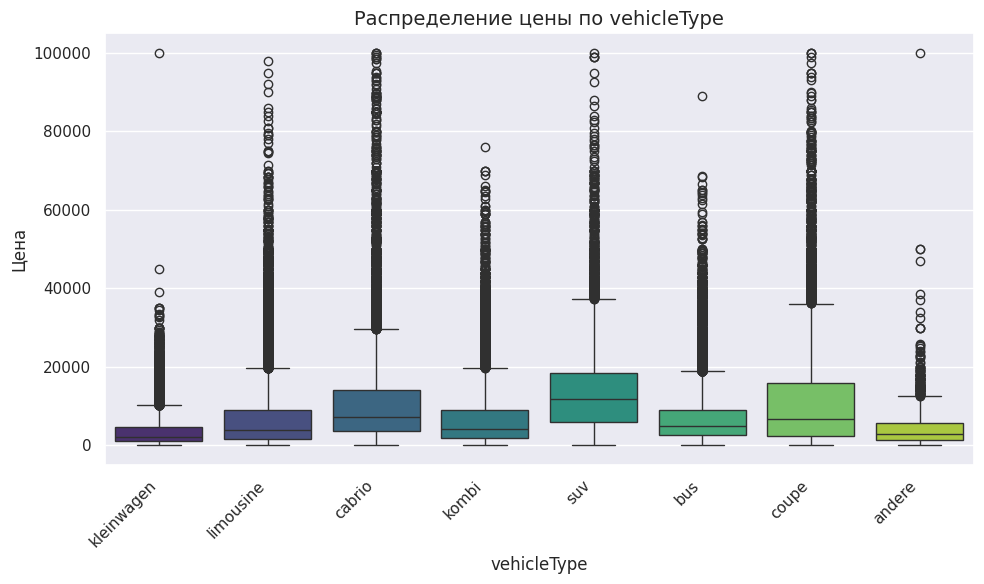

<ipython-input-22-36367a6e2175>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=feature, y=price, palette="viridis"  )


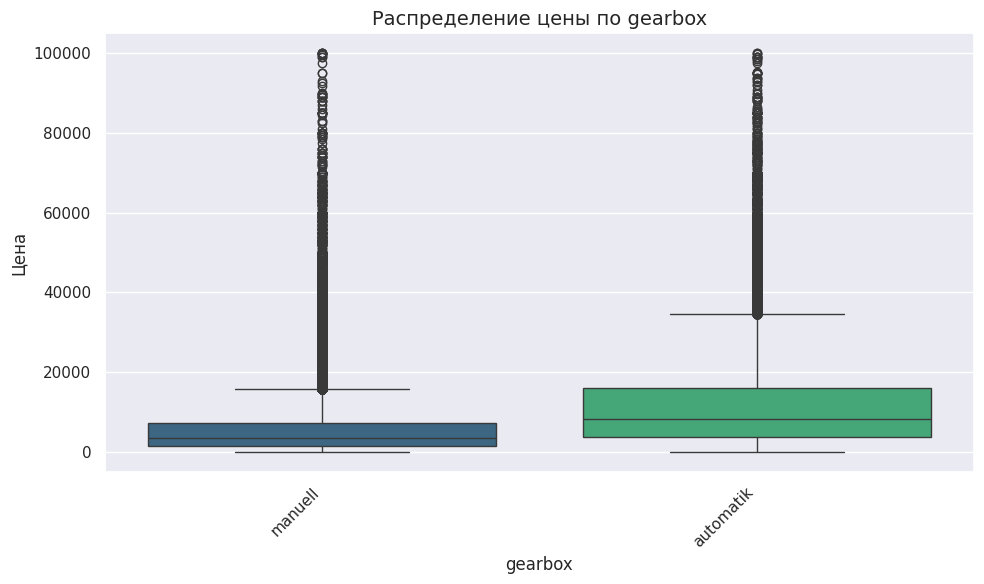

<ipython-input-22-36367a6e2175>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=feature, y=price, palette="viridis"  )


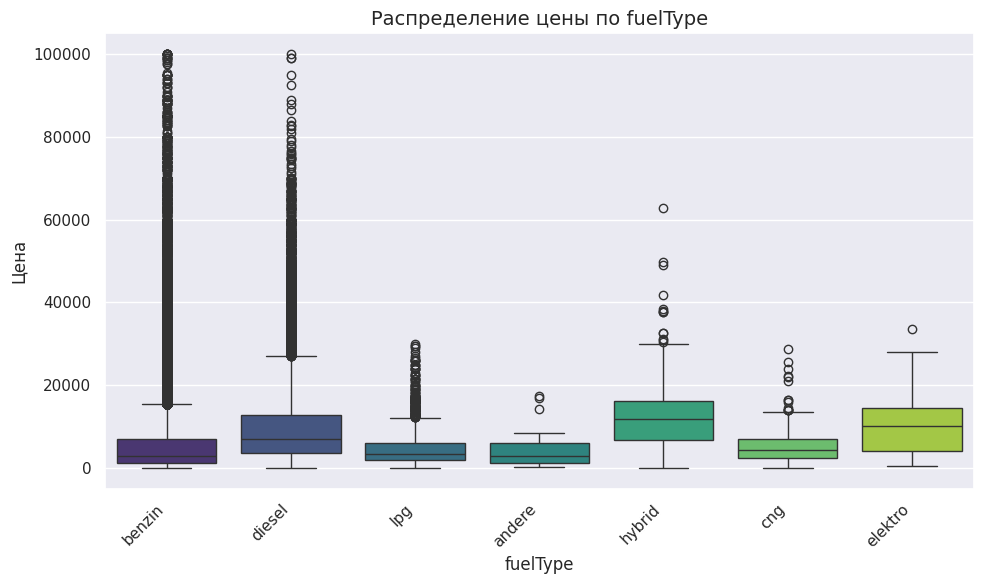

<ipython-input-22-36367a6e2175>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=feature, y=price, palette="viridis"  )


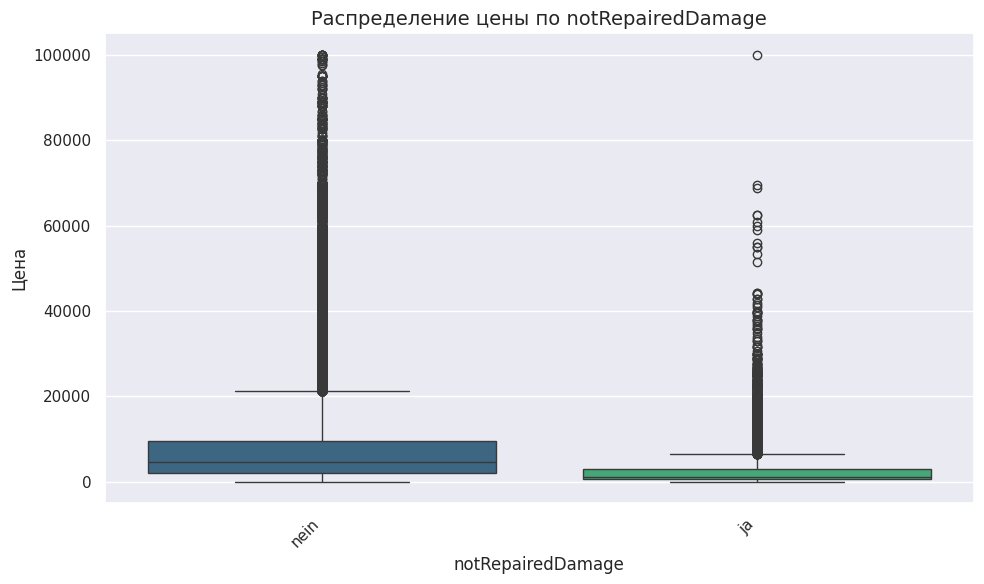

In [22]:
categorical_features = ['brand',  'vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']

price = 'price'

# Построим боксплоты для каждого категориального признака
for feature in categorical_features:
    plt.figure(figsize=(10, 6))

    sns.boxplot(data=data, x=feature, y=price, palette="viridis"  )

    plt.title(f"Распределение цены по {feature}", fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Цена', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

Верхние выбросы в категориальных признаках  связаны  с премиальными брендами и с редкими комбинациями характеристик, как гибридные двигатели  

<ipython-input-23-3a5007774b4a>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=medians.index, y=medians.values, palette='viridis', ax=ax2)
<ipython-input-23-3a5007774b4a>:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


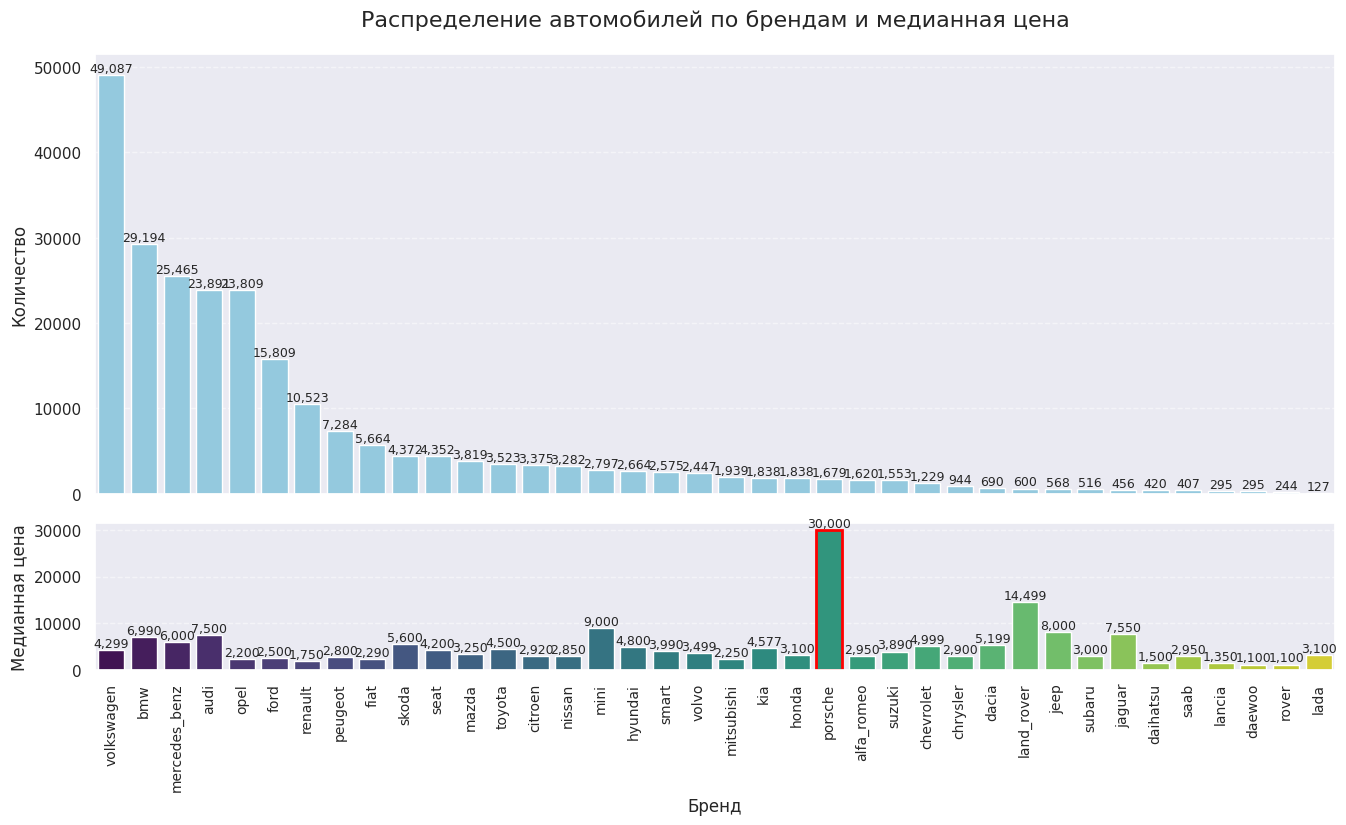

In [23]:
# Взглянем подробно на распределение автомобилей по брендам и медианной цене

TITLE_SIZE = 16
LABEL_SIZE = 12
TICK_SIZE = 10
COLOR1 = 'skyblue'
COLOR2 = 'crimson'
PALETTE = 'viridis'

plt.figure(figsize=(16, 8))
grid = plt.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.1)

ax1 = plt.subplot(grid[0])
counts = data['brand'].value_counts().sort_values(ascending=False)
sns.barplot(x=counts.index, y=counts.values, color='skyblue', ax=ax1)
plt.title('Распределение автомобилей по брендам и медианная цена', fontsize=16, pad=20)
plt.xlabel('')
plt.ylabel('Количество', fontsize=12)
plt.xticks([])
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, count in enumerate(counts):
    ax1.text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=9)

ax2 = plt.subplot(grid[1])
medians = data.groupby('brand')['price'].median().loc[counts.index]
sns.barplot(x=medians.index, y=medians.values, palette='viridis', ax=ax2)
plt.xlabel('Бренд', fontsize=12)
plt.ylabel('Медианная цена', fontsize=12)
plt.xticks(rotation=90, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, price in enumerate(medians):
    ax2.text(i, price, f'{int(price):,}', ha='center', va='bottom', fontsize=9)

max_brand = medians.idxmax()
max_idx = list(medians.index).index(max_brand)
ax2.patches[max_idx].set_edgecolor('red')
ax2.patches[max_idx].set_linewidth(2)

plt.tight_layout()
plt.show()

Премиальные бренды  имеют цены в 2-3 раза выше, чем  бюджетные бренды. Создадим признак премиального бренда  из топ 3 по медианной цене и добавим их в датасет

In [24]:
premium = ['porsche', 'mini', 'land_rover']
data['is_premium'] = data['brand'].isin(premium).astype(int)

In [25]:
data['is_premium'].value_counts().reset_index()

,is_premium,count
0,0,236114
1,1,5076


In [26]:
# Удалим выбросы
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = data[(data['price'] <= upper_bound) & (data['price'] >= lower_bound)].copy()


print(f"Исходный датасет: {len(data)}")
print(f"Датасет после удаления выбросов: {len(df)}")
print(f"Удалено выбросов: {len(data) - len(df)}")

Исходный датасет: 241190
Датасет после удаления выбросов: 225573
Удалено выбросов: 15617


In [27]:
categorical = ['brand', 'model', 'vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage','is_premium' ]
numeric = ['powerPS', 'kilometer', 'autoAgeMonths']
other = []
target = 'price'

In [28]:
df['bias'] = 1
other += ['bias']

x = df[categorical + numeric + other]
y = df['price']

In [29]:
df.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price,is_premium,bias
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500,0,1
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600,0,1
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650,0,1
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200,0,1
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000,0,1


In [30]:
# Разделим датасет
from sklearn.model_selection import train_test_split
train, temp = train_test_split(df, test_size=0.2, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)


total = len(df)
print(f"Total: {total}")
print(f"Train: {len(train)} ({len(train)/total:.1%})")
print(f"Val: {len(val)} ({len(val)/total:.1%})")
print(f"Test: {len(test)} ({len(test)/total:.1%})")

Total: 225573
Train: 180458 (80.0%)
Val: 22557 (10.0%)
Test: 22558 (10.0%)


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('scaling', StandardScaler(), numeric),
    ('other',  'passthrough', other)
])



In [32]:
X_train = column_transformer.fit_transform(train[categorical + numeric + other])
y_train = train['price']


X_val = column_transformer.transform(val[categorical + numeric + other])
y_val = val['price']

X_test = column_transformer.transform(test[categorical + numeric + other])
y_test = test['price']

## Задание 5. Сравнение методов градиентного спуска (1 балл)

В этом задании вам предстоит сравнить методы градиентного спуска на подготовленных вами данных из предыдущего задания.

### Задание 5.1. Подбор оптимальной длины шага (0.5 балла)

Процесс выбора наиболее подходящего размера шага $\lambda$ для различных методов, с учетом валидационного набора данных, предполагает выполнение следующих шагов:

1. **Определение диапазона для $\lambda$**: Начните с выбора диапазона значений $\lambda$, используя логарифмическую сетку от $10^{-4}$ до $10^1$, чтобы обеспечить широкий охват потенциально оптимальных значений.

2. **Перебор значений $\lambda$**: Для каждого значения из выбранной сетки $\lambda$:
   - Произведите обучение модели на обучающем наборе данных.
   - Вычислите ошибку на обучающем и валидационном наборах данных.
   - Определите значение метрики $R^2$ как на обучающем, так и на валидационном наборах.
   - Зафиксируйте количество итераций, необходимое для достижения сходимости.

3. **Оценка полученных результатов**:
   - Составьте графики, отображающие зависимость ошибки от количества итераций для каждого значения $\lambda$ по всем рассматриваемым методам.
   - Сравните методы на основе скорости сходимости, размера ошибки и значения метрики $R^2$ на различных наборах данных.

4. **Выбор наилучшего $\lambda$**: Исходя из проведенного анализа, определите наиболее подходящее значение $\lambda$ для каждого метода, обеспечивающее оптимальное сочетание скорости сходимости и качества модели на валидационной выборке.

5. **Формулировка выводов**: Подведите итоги, указав, какой метод показал наилучшую производительность с точки зрения соотношения скорости сходимости к качеству предсказаний. Также отметьте, как изменение $\lambda$ влияет на результаты каждого из методов.



In [33]:
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from descents import get_descent
from linear_regression import LinearRegression


X_train_np = X_train.toarray()
X_val_np = X_val.toarray()
X_test_np = X_test.toarray()

y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
y_test_np = y_test.to_numpy()

# Определяем диапазон значений λ (логарифмическая сетка)
lambda_values = np.logspace(-4, 1, 10)

# Выбираем методы градиентного спуска для тестирования
descent_methods = ["full", "stochastic", "momentum", "adam"]

# Хранение результатов по каждому методу
method_results = {method: {
    "lambda": [], "train_mse": [], "val_mse": [], "train_r2": [], "val_r2": [], "iterations": []
} for method in descent_methods}

# Перебор методов градиентного спуска
for descent_name in descent_methods:
    print(f"\nTesting descent method: {descent_name}")

    for lambda_ in tqdm(lambda_values, desc=f"Lambda tuning for {descent_name}"):
        # Создаём конфиг градиентного спуска
        descent_config = {
            "descent_name": descent_name,
            "kwargs": {"dimension": X_train_np.shape[1], "lambda_": lambda_}
        }

        # Инициализируем линейную регрессию
        model = LinearRegression(descent_config=descent_config, max_iter=1000, tolerance=1e-4)

        # Обучаем модель
        model.fit(X_train_np, y_train_np)

        # Предсказания
        y_train_pred = model.predict(X_train_np)
        y_val_pred = model.predict(X_val_np)

        # Вычисляем метрики
        train_mse = mean_squared_error(y_train_np, y_train_pred)
        val_mse = mean_squared_error(y_val_np, y_val_pred)
        train_r2 = r2_score(y_train_np, y_train_pred)
        val_r2 = r2_score(y_val_np, y_val_pred)

        # Сохраняем результаты
        method_results[descent_name]["lambda"].append(lambda_)
        method_results[descent_name]["train_mse"].append(train_mse)
        method_results[descent_name]["val_mse"].append(val_mse)
        method_results[descent_name]["train_r2"].append(train_r2)
        method_results[descent_name]["val_r2"].append(val_r2)
        method_results[descent_name]["iterations"].append(len(model.loss_history))


Testing descent method: full


Lambda tuning for full:  90%|█████████ | 9/10 [07:01<00:46, 46.67s/it]/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/content/descents.py:203: RuntimeWarning: overflow encountered in square
  return np.mean((y_pred - y) ** 2)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1275: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)
/usr/local/lib/python3.11/dist-packages/sklearn


Testing descent method: stochastic


Lambda tuning for stochastic:  90%|█████████ | 9/10 [01:04<00:07,  7.17s/it]/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/content/descents.py:203: RuntimeWarning: overflow encountered in square
  return np.mean((y_pred - y) ** 2)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1275: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)
/usr/local/lib/python3.11/dist-packages/s


Testing descent method: momentum


Lambda tuning for momentum:  90%|█████████ | 9/10 [07:02<00:47, 47.47s/it]/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/content/descents.py:203: RuntimeWarning: overflow encountered in square
  return np.mean((y_pred - y) ** 2)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1275: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)
/usr/local/lib/python3.11/dist-packages/skl


Testing descent method: adam


Lambda tuning for adam: 100%|██████████| 10/10 [08:02<00:00, 48.25s/it]


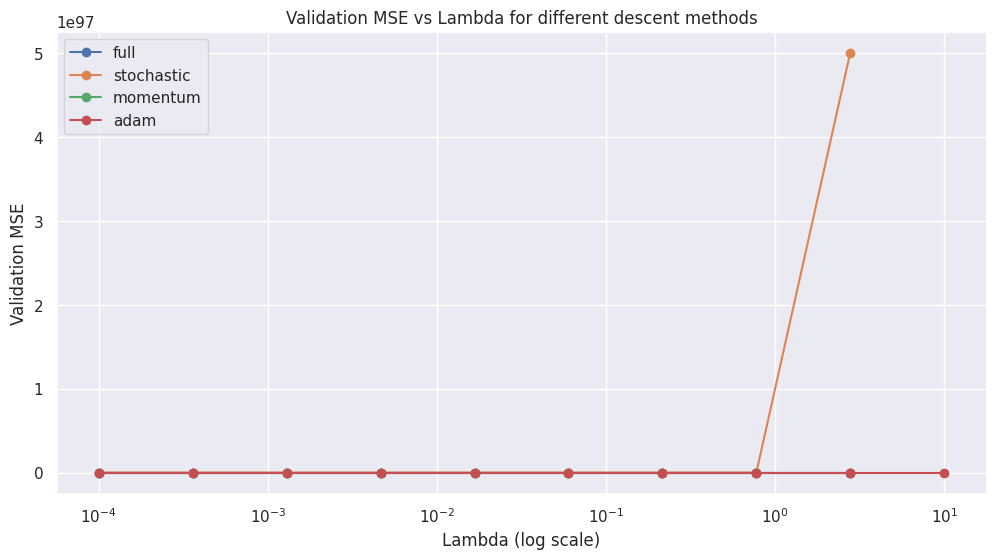

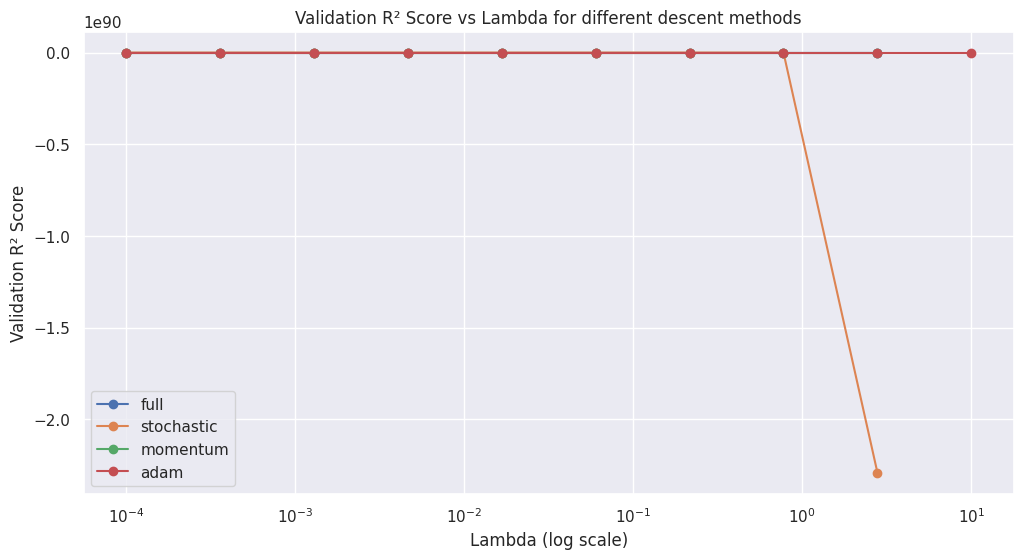

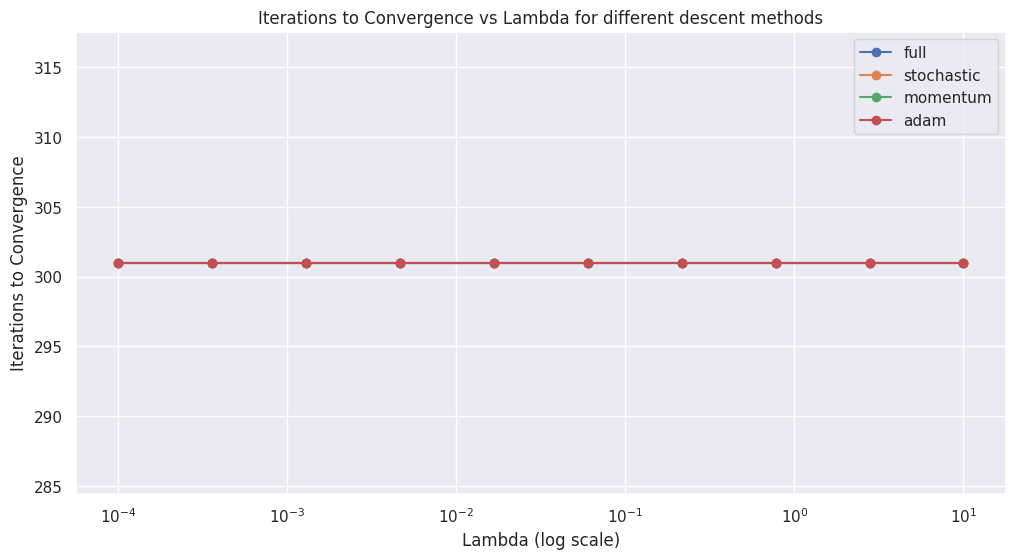

In [34]:
# Визуализация результатов
plt.figure(figsize=(12, 6))
for method in descent_methods:
    plt.plot(method_results[method]["lambda"], method_results[method]["val_mse"], marker="o", label=f"{method}")

plt.xscale("log")
plt.xlabel("Lambda (log scale)")
plt.ylabel("Validation MSE")
plt.title("Validation MSE vs Lambda for different descent methods")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
for method in descent_methods:
    plt.plot(method_results[method]["lambda"], method_results[method]["val_r2"], marker="o", label=f"{method}")

plt.xscale("log")
plt.xlabel("Lambda (log scale)")
plt.ylabel("Validation R² Score")
plt.title("Validation R² Score vs Lambda for different descent methods")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
for method in descent_methods:
    plt.plot(method_results[method]["lambda"], method_results[method]["iterations"], marker="o", label=f"{method}")

plt.xscale("log")
plt.xlabel("Lambda (log scale)")
plt.ylabel("Iterations to Convergence")
plt.title("Iterations to Convergence vs Lambda for different descent methods")
plt.legend()
plt.show()

In [35]:
best_lambdas = {}

for method in descent_methods:
    # Находим индекс минимального MSE на валидации для текущего метода
    min_mse_idx = np.argmin(method_results[method]["val_mse"])

    # Извлекаем соответствующие значения
    best_lambdas[method] = {
        "lambda": method_results[method]["lambda"][min_mse_idx],
        "val_mse": method_results[method]["val_mse"][min_mse_idx],
        "val_r2": method_results[method]["val_r2"][min_mse_idx],
        "iterations": method_results[method]["iterations"][min_mse_idx],
    }

# Создаем DataFrame и выводим первые строки
best_lambda_df = pd.DataFrame(best_lambdas).T
best_lambda_df.head()

,lambda,val_mse,val_r2,iterations
full,0.774264,6.375112e+06,0.708325,301.0
stochastic,0.215443,6.798737e+06,0.688943,301.0
momentum,0.774264,5.953895e+06,0.727597,301.0
adam,10.000000,2.665704e+07,-0.219617,301.0


### Задание 5.2. Сравнение методов (0.5 балла)

Создайте график, на котором будет показана динамика изменения ошибки на обучающей выборке в зависимости от номера итерации для каждого из рассматриваемых методов. Разместите линии, представляющие каждый метод, на одном и том же графике для наглядного сравнения.

После анализа результатов, представленных в виде графика и таблиц с метриками, выполните сравнение методов. Обратите внимание на следующие аспекты:
- Как быстро каждый метод сходится к минимуму ошибки.
- Величину ошибки на обучающей и тестовой выборках для каждого метода.
- Значение метрики $R^2$ для каждого метода на обучающей и тестовой выборках.
- Количество итераций, необходимых для достижения сходимости.

На основе этих данных сделайте вывод о преимуществах и недостатках каждого из методов в контексте вашей задачи.

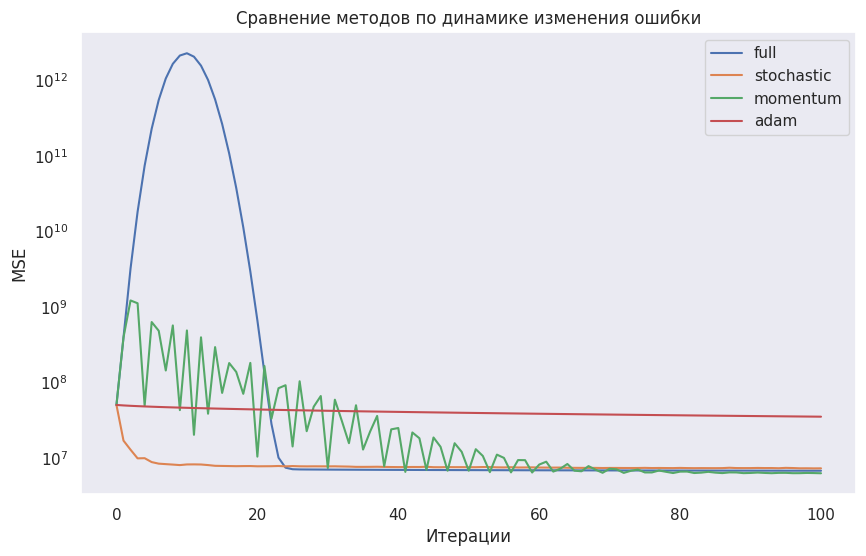

In [36]:
# Словарь для хранения истории потерь каждого метода
loss_histories = {}

# Перебираем каждый метод с оптимальной λ и обучаем модель
for method, row in best_lambda_df.iterrows():
    lambda_opt = row["lambda"]

    descent_config = {
        "descent_name": method,
        "kwargs": {
            "dimension": X_train_np.shape[1],
            "lambda_": lambda_opt,
        }
    }

    # Создаем и обучаем модель (исправлен вызов конструктора)
    model = LinearRegression(descent_config=descent_config, max_iter=100)
    model.fit(X_train_np, y_train_np)

    # Сохраняем историю потерь
    loss_histories[method] = model.loss_history

# Построение графика
plt.figure(figsize=(10, 6))

for method, loss_history in loss_histories.items():
    plt.plot(range(len(loss_history)), loss_history, label=method)

plt.xlabel("Итерации")
plt.ylabel("MSE")
plt.yscale("log")  # Логарифмическая шкала для наглядности
plt.title("Сравнение методов по динамике изменения ошибки")
plt.legend()
plt.grid()
plt.show()

In [37]:
# Функция для определения момента сходимости
def find_convergence_point(loss_history, tolerance=1e-4):
    for i in range(1, len(loss_history)):
        if abs(loss_history[i] - loss_history[i - 1]) < tolerance:
            return i
    return len(loss_history)

# Словарь для хранения количества итераций до сходимости
convergence_results = {}

# Проходим по каждому методу и вычисляем момент сходимости
for method, loss_history in loss_histories.items():
    convergence_results[method] = find_convergence_point(loss_history)

# Создаем DataFrame с результатами
convergence_df = pd.DataFrame.from_dict(convergence_results, orient='index', columns=['Iterations to Converge'])
convergence_df.head()

,Iterations to Converge
full,101
stochastic,101
momentum,101
adam,101


Графики показывают, что  адаптивные методы, такие как Adam и Momentum, демонстрируют повышенную устойчивость к изменениям Lambda благодаря механизмам адаптивного шага и учета инерции градиентов, что позволяет им избегать резких колебаний ошибки и быстрее достигать сходимости. При этом слишком малые значения Lambda могут приводить к переобучению, а слишком большие — к недообучению. Взрыв градиентов, наблюдаемый у методов вроде стохастического градиентного спуска, связан с отсутствием регуляризации, высоким learning rate

## Задание 6. Стохастический градиентный спуск и размер батча (0.5 балла)

Ваша задача — исследовать, как размер батча влияет на процесс обучения при использовании стохастического градиентного спуска (SGD). Выполните следующие шаги:

1. **Выбор размеров батча**: Определите ряд значений для размера батча, которые вы хотите исследовать. Это могут быть, например, %1$, $10$, $50$, $100$, $500$, и так далее.

2. **Многократные запуски для каждого размера батча**: Для каждого выбранного размера батча проведите $k$ независимых запусков стохастического градиентного спуска на обучающей выборке. $k$ может быть равно, например, $10$. Для каждого запуска замерьте:
   - Время обучения в секундах до достижения сходимости.
   - Количество итераций (шагов), необходимых для сходимости.

3. **Вычисление средних значений**: Рассчитайте среднее время обучения и среднее количество итераций до сходимости для каждого размера батча.

4. **Построение графиков**:
   - Постройте график, показывающий зависимость среднего количества итераций до сходимости от размера батча.
   - Постройте график, показывающий зависимость среднего времени обучения от размера батча.

5. **Анализ результатов**: Оцените, как размер батча влияет на скорость и эффективность обучения. Сделайте выводы о том, какой размер батча может быть оптимальным с точки зрения баланса между временем обучения и количеством итераций до сходимости.

Этот эксперимент поможет вам лучше понять влияние размера батча на процесс обучения стохастического градиентного спуска и как этот параметр можно настроить для улучшения производительности обучения.

Testing batch sizes: 100%|██████████| 5/5 [03:06<00:00, 37.24s/it]


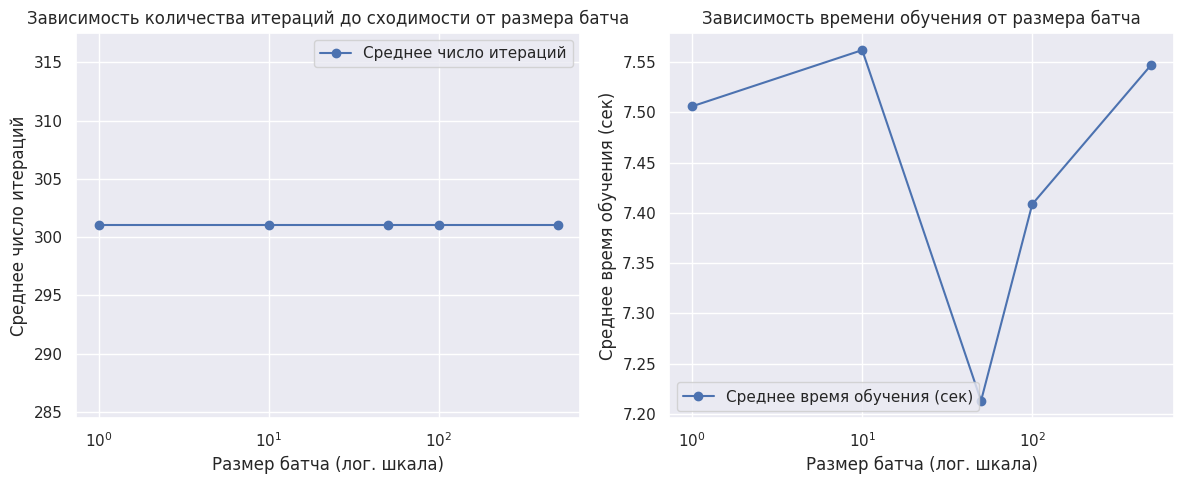

In [38]:
import time


# Определение момента сходимости
def find_convergence_point(loss_history, tolerance=1e-4):
    for i in range(1, len(loss_history)):
        if abs(loss_history[i] - loss_history[i - 1]) < tolerance:
            return i
    return len(loss_history)

batch_sizes = [1, 10, 50, 100, 500]

num_runs = 5  # Количество запусков для усреднения

# Порог сходимости
tolerance = 1e-4

# Хранение результатов
results = {
    "batch_size": [],
    "avg_iterations": [],
    "avg_time": []
}

# Тестирование разных размеров батча
for batch_size in tqdm(batch_sizes, desc="Testing batch sizes"):
    iterations_list = []
    time_list = []

    for _ in range(num_runs):
        # Создаем конфигурацию градиентного спуска
        descent_config = {
            "descent_name": "stochastic",
            "kwargs": {"dimension": X_train_np.shape[1], "batch_size": batch_size}
        }

        # Создаем и обучаем модель
        model = LinearRegression(descent_config=descent_config, tolerance=tolerance, max_iter=300)
        start_time = time.time()
        model.fit(X_train_np, y_train_np)
        end_time = time.time()

        # Определяем момент сходимости
        convergence_iter = find_convergence_point(model.loss_history, tolerance)

        # Фиксируем количество итераций до сходимости
        iterations_list.append(convergence_iter)
        time_list.append(end_time - start_time)

    # Считаем среднее количество итераций и время
    results["batch_size"].append(batch_size)
    results["avg_iterations"].append(np.mean(iterations_list))
    results["avg_time"].append(np.mean(time_list))

# Преобразуем результаты в DataFrame
df_results = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График количества итераций до сходимости
axes[0].plot(df_results["batch_size"], df_results["avg_iterations"], marker="o", label="Среднее число итераций")
axes[0].set_xscale("log")
axes[0].set_xlabel("Размер батча (лог. шкала)")
axes[0].set_ylabel("Среднее число итераций")
axes[0].set_title("Зависимость количества итераций до сходимости от размера батча")
axes[0].legend()

# График времени обучения
axes[1].plot(df_results["batch_size"], df_results["avg_time"], marker="o", label="Среднее время обучения (сек)")
axes[1].set_xscale("log")
axes[1].set_xlabel("Размер батча (лог. шкала)")
axes[1].set_ylabel("Среднее время обучения (сек)")
axes[1].set_title("Зависимость времени обучения от размера батча")
axes[1].legend()

plt.tight_layout()
plt.show()

При малых размерах батча (например, 1) количество итераций до сходимости максимально. Это связано с тем, что маленькие батчи содержат мало данных, что приводит к шумным и менее точным обновлениям параметров.
С увеличением размера батча (например, до 10 или 100) количество итераций сокращается. Большие батчи обеспечивают более стабильные оценки градиента, что ускоряет сходимость.
Однако при слишком больших батчах (например, 100) может наблюдаться замедление сходимости из-за редких обновлений параметров или вычислительных ограничений.

## Задание 7. Регуляризация (0.5 балла)

В этом задании вам предстоит исследовать влияние регуляризации на работу различных методов градиентного спуска. Напомним, регуляризация - это добавка к функции потерь, которая штрафует за норму весов. Мы будем использовать l2 регуляризацию, таким образом функция потерь приобретает следующий вид:

$$
    Q(w) = \dfrac{1}{\ell} \sum\limits_{i=1}^{\ell} (a_w(x_i) - y_i)^2 + \dfrac{\mu}{2} \| w \|^2
$$

Допишите класс **BaseDescentReg** в файле `descents.py`.

Найдите лучшие параметры обучения с регуляризацией аналогично 5 заданию. Вам предстоит исследовать, как настройка параметров обучения с включением регуляризации влияет на различные методы градиентного спуска. Основная цель — определить оптимальные значения для длины шага $\lambda$ и коэффициента регуляризации $\mu$, а затем сравнить результаты обучения с регуляризацией и без неё по нескольким критериям.

Ваш план действий следующий:

1. **Выбор параметров для подбора**: Установите диапазон значений для длины шага $\lambda$ и коэффициента регуляризации $\mu$. Используйте логарифмическую сетку для обоих параметров, чтобы обеспечить широкий охват потенциально оптимальных значений.

2. **Оптимизация и сравнение методов градиентного спуска**:
   - Произведите подбор параметров для каждого метода градиентного спуска, исследуя их влияние на процесс обучения.
   - Замерьте и сравните ошибку и качество по метрике $R^2$ на обучающей и тестовой выборках, а также количество итераций до сходимости для моделей с регуляризацией и без неё.

3. **Визуализация результатов**:
   - Постройте для каждого метода графики, отображающие значения функции потерь (MSE) с регуляризацией и без неё на протяжении процесса обучения.

4. **Анализ результатов**:
   - Оцените, как регуляризация повлияла на сходимость методов.
   - Сравните качество моделей на обучающей и тестовой выборках с учетом регуляризации и без неё.
   - Проанализируйте, как изменения в длине шага и коэффициенте регуляризации отразились на итоговых результатах.

5. **Формулировка выводов**:
   - Сделайте выводы о влиянии регуляризации на процесс обучения и качество модели. Как регуляризация влияет на переобучение и обобщающую способность модели.
   - Рассмотрите, в каких случаях регуляризация приводит к улучшению результатов, и когда её вклад может быть минимальным или отрицательным.


In [39]:
from descents import get_descent

descent_config = {
    "descent_name": "full",
    "regularized": True,
    "kwargs": {"dimension": 10, "lambda_": 0.01, "mu": 0.1}
}
descent = get_descent(descent_config)
print(type(descent))

<class 'descents.VanillaGradientDescentReg'>


In [41]:
from descents import (
    VanillaGradientDescentReg, StochasticDescentReg, MomentumDescentReg, AdamReg,
    VanillaGradientDescent, StochasticDescent, MomentumDescent, Adam, get_descent
)
from linear_regression import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Создаем соответствие методов градиентного спуска
descent_mapping = {
    'full': VanillaGradientDescent,
    'stochastic': StochasticDescent,
    'momentum': MomentumDescent,
    'adam': Adam,
    'full_reg': VanillaGradientDescentReg,
    'stochastic_reg': StochasticDescentReg,
    'momentum_reg': MomentumDescentReg,
    'adam_reg': AdamReg
}

# Определяем диапазоны значений λ и μ
lambda_values = np.logspace(-4, 1, 5)  # 5 значений для lambda
mu_values = np.logspace(-4, 1, 5)  # 5 значений для mu

# Уменьшаем размер выборки для ускорения вычислений
X_train_sample = X_train_np[:5000]
y_train_sample = y_train_np[:5000]
X_test_sample = X_test_np[:1000]
y_test_sample = y_test_np[:1000]

# Словарь для хранения результатов
results = []

# Проходим по каждому методу градиентного спуска
for method_name, descent_class in descent_mapping.items():
    print(f"Testing descent method: {method_name}")

    for lambda_ in tqdm(lambda_values, desc=f"Lambda tuning for {method_name}", leave=False):
        for mu in mu_values:
            try:
                # Создаем конфигурацию градиентного спуска
                descent_config = {
                    "descent_name": method_name.replace("_reg", ""),
                    "regularized": "reg" in method_name,
                    "kwargs": {
                        "dimension": X_train_sample.shape[1],
                        "lambda_": lambda_,
                    }
                }
                if "reg" in method_name:
                    descent_config["kwargs"]["mu"] = mu

                # Создаем и обучаем модель
                model = LinearRegression(descent_config=descent_config, max_iter=300, tolerance=1e-4)
                start_time = time.time()
                model.fit(X_train_sample, y_train_sample)
                end_time = time.time()

                # Проверка инициализации весов
                if not hasattr(model.descent, 'w') or model.descent.w is None:
                    raise ValueError(f"Weights not initialized for {method_name}")

                # Предсказания
                y_train_pred = model.predict(X_train_sample)
                y_test_pred = model.predict(X_test_sample)

                # Метрики
                train_mse = mean_squared_error(y_train_sample, y_train_pred)
                test_mse = mean_squared_error(y_test_sample, y_test_pred)
                train_r2 = r2_score(y_train_sample, y_train_pred)
                test_r2 = r2_score(y_test_sample, y_test_pred)

                # Фиксируем результаты
                results.append({
                    "method": method_name,
                    "lambda": lambda_,
                    "mu": mu,
                    "train_mse": train_mse,
                    "test_mse": test_mse,
                    "train_r2": train_r2,
                    "test_r2": test_r2,
                    "iterations": len(model.loss_history),
                    "time": end_time - start_time
                })

            except Exception as e:
                print(f"Ошибка в методе {method_name}, lambda={lambda_}, mu={mu}: {str(e)}")
                continue

# Преобразуем в DataFrame
df_results = pd.DataFrame(results)

# Выводим первые строки
df_results.head()

Testing descent method: full


Lambda tuning for full:  80%|████████  | 4/5 [00:18<00:04,  4.67s/it]/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/content/descents.py:203: RuntimeWarning: overflow encountered in square
  return np.mean((y_pred - y) ** 2)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1275: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)
/usr/local/lib/python3.11/dist-packages/sklearn/

Testing descent method: stochastic


Lambda tuning for stochastic:  80%|████████  | 4/5 [00:02<00:00,  1.62it/s]/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/content/descents.py:203: RuntimeWarning: overflow encountered in square
  return np.mean((y_pred - y) ** 2)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1275: RuntimeWarning: overflow encountered in square
  numerator = xp.sum(weight * (y_true - y_pred) ** 2, axis=0)
/usr/local/lib/python3.11/dist-packages/sk

Testing descent method: momentum


...

Lambda tuning for stochastic_reg:  80%|████████  | 4/5 [00:02<00:00,  1.54it/s]/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/content/descents.py:203: RuntimeWarning: overflow encountered in square
  return np.mean((y_pred - y) ** 2)
/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/content/descents.py:580: RuntimeWarning: overflow encountered in square
  reg_loss = 0.5 * self.mu * np.sum(self.w ** 2)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  outpu

Ошибка в методе stochastic_reg, lambda=10.0, mu=10.0: Input contains NaN.
Testing descent method: momentum_reg


Lambda tuning for momentum_reg:  80%|████████  | 4/5 [00:18<00:04,  4.67s/it]/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/content/descents.py:203: RuntimeWarning: overflow encountered in square
  return np.mean((y_pred - y) ** 2)
/content/descents.py:580: RuntimeWarning: overflow encountered in square
  reg_loss = 0.5 * self.mu * np.sum(self.w ** 2)
/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:570: RuntimeWarning: overflow encountered in square
  output_

Ошибка в методе momentum_reg, lambda=10.0, mu=10.0: Input contains NaN.
Testing descent method: adam_reg


,method,lambda,mu,train_mse,test_mse,train_r2,test_r2,iterations,time
0,full,0.0001,0.000100,4.628035e+07,4.669970e+07,-1.223873,-1.169917,301,0.850605
1,full,0.0001,0.001778,4.626760e+07,4.668640e+07,-1.223261,-1.169299,301,0.730893
2,full,0.0001,0.031623,4.627021e+07,4.668901e+07,-1.223386,-1.169420,301,1.594622
3,full,0.0001,0.562341,4.628283e+07,4.670151e+07,-1.223992,-1.170001,301,1.277859
4,full,0.0001,10.000000,4.627326e+07,4.669206e+07,-1.223532,-1.169562,301,0.869744


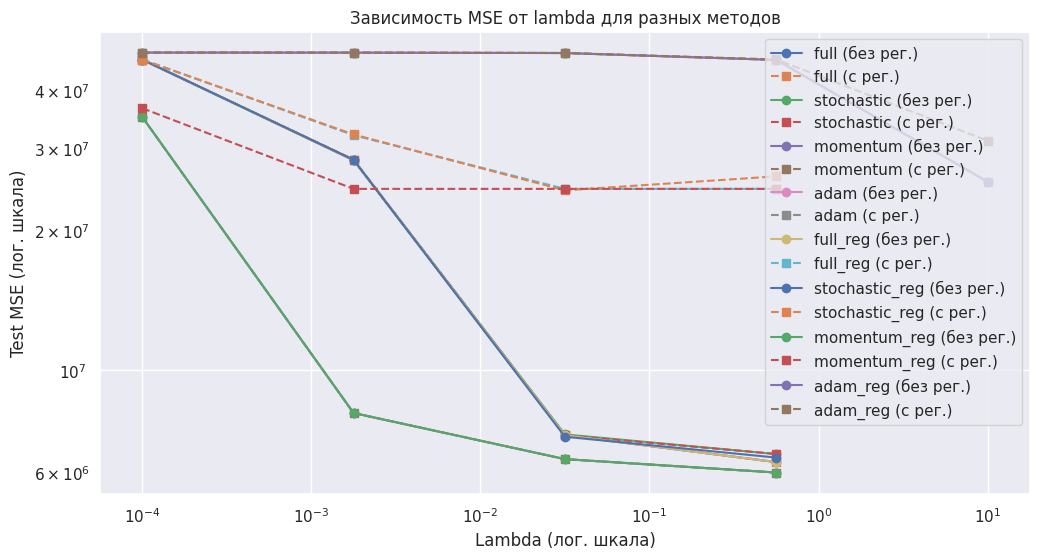

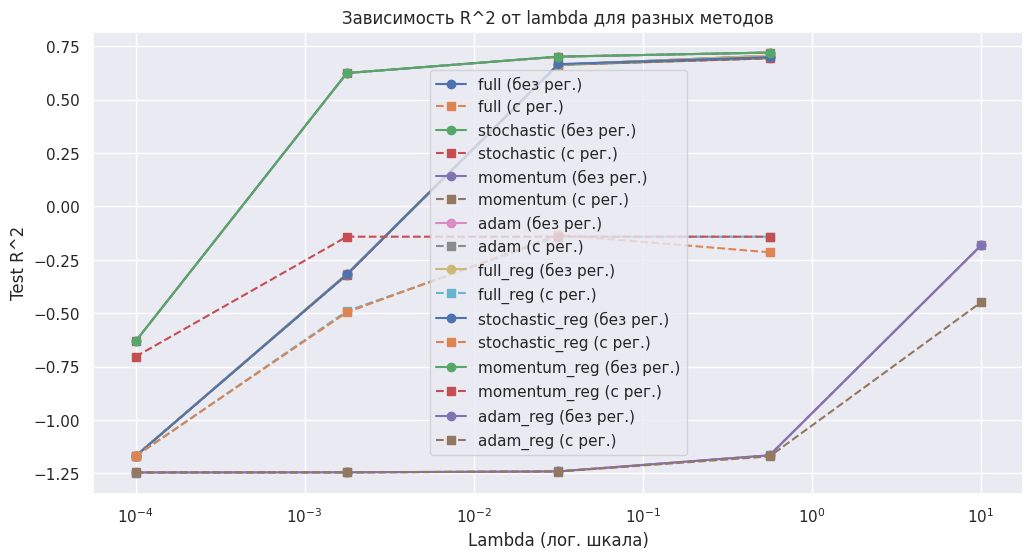

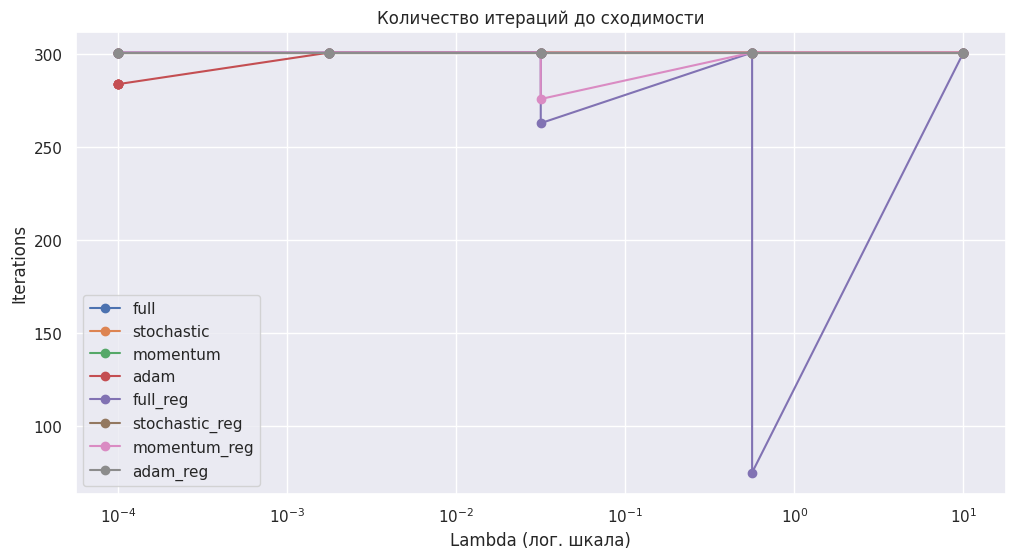

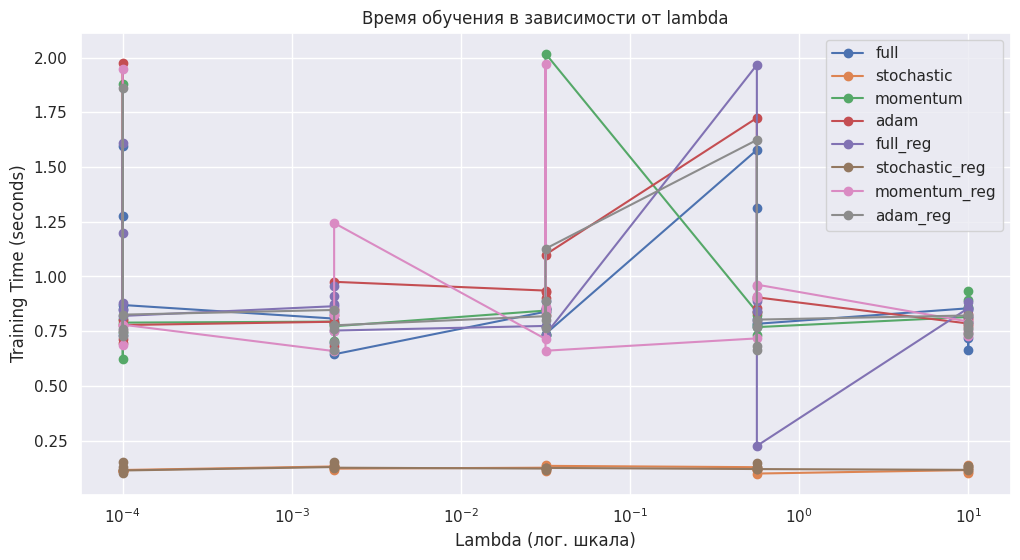

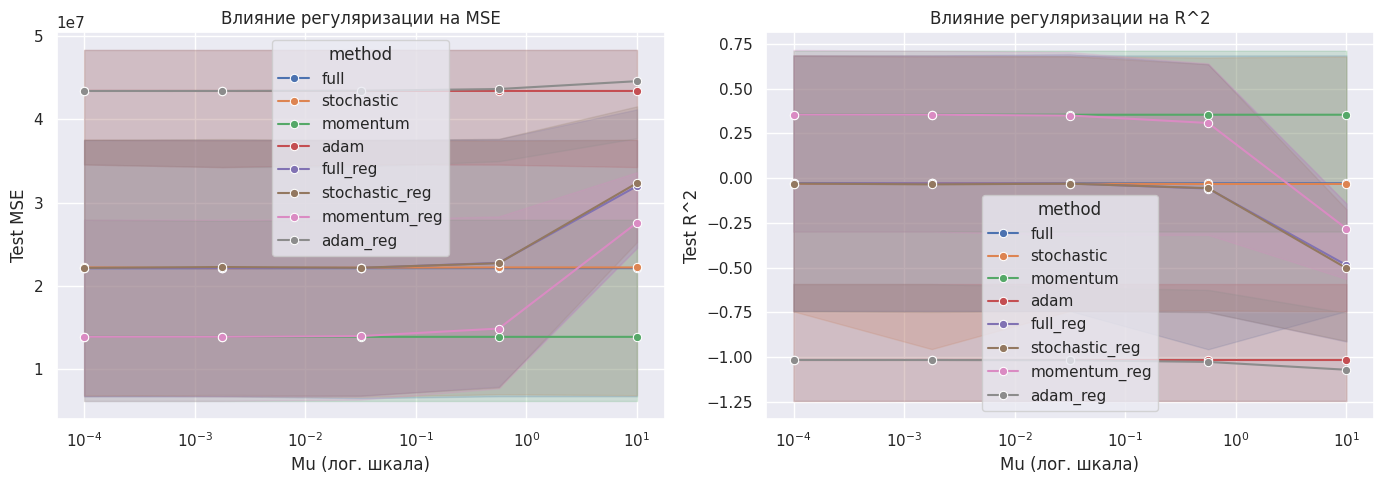

In [42]:
methods = df_results["method"].unique()

plt.figure(figsize=(12, 6))
for method in methods:
    subset = df_results[df_results["method"] == method]
    subset_no_reg = subset[subset["mu"] == min(subset["mu"])]  # Без регуляризации (наименьший mu)
    subset_reg = subset[subset["mu"] == max(subset["mu"])]  # Сильная регуляризация (наибольший mu)

    plt.plot(subset_no_reg["lambda"], subset_no_reg["test_mse"], marker="o", label=f"{method} (без рег.)")
    plt.plot(subset_reg["lambda"], subset_reg["test_mse"], marker="s", linestyle="--", label=f"{method} (с рег.)")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Lambda (лог. шкала)")
plt.ylabel("Test MSE (лог. шкала)")
plt.title("Зависимость MSE от lambda для разных методов")
plt.legend()
plt.grid(True)
plt.show()

# 2. Графики R^2 от lambda
plt.figure(figsize=(12, 6))
for method in methods:
    subset = df_results[df_results["method"] == method]
    subset_no_reg = subset[subset["mu"] == min(subset["mu"])]
    subset_reg = subset[subset["mu"] == max(subset["mu"])]

    plt.plot(subset_no_reg["lambda"], subset_no_reg["test_r2"], marker="o", label=f"{method} (без рег.)")
    plt.plot(subset_reg["lambda"], subset_reg["test_r2"], marker="s", linestyle="--", label=f"{method} (с рег.)")

plt.xscale("log")
plt.xlabel("Lambda (лог. шкала)")
plt.ylabel("Test R^2")
plt.title("Зависимость R^2 от lambda для разных методов")
plt.legend()
plt.grid(True)
plt.show()

# 3. Количество итераций до сходимости
plt.figure(figsize=(12, 6))
for method in methods:
    subset = df_results[df_results["method"] == method]
    plt.plot(subset["lambda"], subset["iterations"], marker="o", label=method)

plt.xscale("log")
plt.xlabel("Lambda (лог. шкала)")
plt.ylabel("Iterations")
plt.title("Количество итераций до сходимости")
plt.legend()
plt.grid(True)
plt.show()

# 4. Анализ времени обучения
plt.figure(figsize=(12, 6))
for method in methods:
    subset = df_results[df_results["method"] == method]
    plt.plot(subset["lambda"], subset["time"], marker="o", label=method)

plt.xscale("log")
plt.xlabel("Lambda (лог. шкала)")
plt.ylabel("Training Time (seconds)")
plt.title("Время обучения в зависимости от lambda")
plt.legend()
plt.grid(True)
plt.show()

# 5. Влияние регуляризации на сходимость
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График MSE в зависимости от mu
sns.lineplot(data=df_results, x="mu", y="test_mse", hue="method", marker="o", ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_xlabel("Mu (лог. шкала)")
axes[0].set_ylabel("Test MSE")
axes[0].set_title("Влияние регуляризации на MSE")

# График R^2 в зависимости от mu
sns.lineplot(data=df_results, x="mu", y="test_r2", hue="method", marker="o", ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_xlabel("Mu (лог. шкала)")
axes[1].set_ylabel("Test R^2")
axes[1].set_title("Влияние регуляризации на R^2")

plt.tight_layout()
plt.show()

Адам и Моментум лучше справляются с балансировкой между точностью и скоростью сходимости, особенно при использовании регуляризации, которая смягчает проблемы переобучения и улучшает обобщающую способность модели. Отсутствие регкуляризации приводит к резкому росту ошибки и нестабильности, особенно у методов вроде стохастического градиентного спуска. Стохастические методы демонстрируют повышенную чувствительность к шуму в данных, что требует таких мер  как регуляризация или ограничение градиентов. Адаптивные методы сочетают в себе скорость и надежность, минимизируя риски взрыва градиентов

## Задание 8. Альтернативная функция потерь (0.5 балла)

В этом задании вам предстоит использовать другую функцию потерь для нашей задачи регрессии. В качестве функции потерь мы выбрали **Log-Cosh**:

$$
    L(y, a)
    =
    \log({cosh{(a - y)}}).
$$


Самостоятельно продифференцируйте данную функцию потерь чтобы найти её градиент:

╰( ͡☉ ͜ʖ ͡☉ )つ──☆*:・ﾟ   ฅ^•ﻌ•^ฅ   ʕ•ᴥ•ʔ

Программно реализуйте градиентный спуск с данной функцией потерь в файле `descents.py`, обучите все четыре метода (без регуляризации) аналогично 5 заданию, сравните их качество с четырьмя методами из 5 задания.

Пример того, как можно запрограммировать использование нескольких функций потерь внутри одного класса градиентного спуска:


```python
from enum import auto
from enum import Enum

import numpy as np

class LossFunction(Enum):
    MSE = auto()
    MAE = auto()
    LogCosh = auto()
    Huber = auto()

...
class BaseDescent:
    def __init__(self, loss_function: LossFunction = LossFunction.MSE):
        self.loss_function: LossFunction = loss_function

    def calc_gradient(self, x: np.ndarray, y: np.ndarray) -> np.ndarray:
        if self.loss_function is LossFunction.MSE:
            return ...
        elif self.loss_function is LossFunction.LogCosh:
            return ...
...

```

In [44]:
from descents import VanillaGradientDescent, StochasticDescent, MomentumDescent, Adam, LossFunction, get_descent

# Ограничиваем размер выборки для ускорения вычислений
X_train_sample = X_train_np#[:5000]
y_train_sample = y_train_np#[:5000]
X_test_sample = X_test_np#[:1000]
y_test_sample = y_test_np#[:1000]

# Определяем логарифмическую сетку для lambda
lambda_values = np.logspace(-4, 0, 5)  # 5 значений

# Методы градиентного спуска (без регуляризации)
descent_methods = {
    "full": VanillaGradientDescent,
    "stochastic": StochasticDescent,
    "momentum": MomentumDescent,
    "adam": Adam
}

# Список функций потерь для сравнения
loss_functions = [LossFunction.MSE, LossFunction.LogCosh]

# Словарь для хранения результатов
results = []

# Перебираем методы градиентного спуска
for method_name, descent_class in descent_methods.items():
    print(f"Testing descent method: {method_name}")

    # Перебираем значения lambda
    for lambda_ in tqdm(lambda_values, desc=f"Lambda tuning for {method_name}", leave=False):

        # Перебираем разные функции потерь
        for loss_function in loss_functions:
            descent_config = {
                "descent_name": method_name,
                "kwargs": {
                    "dimension": X_train_sample.shape[1],
                    "lambda_": lambda_,
                    "loss_function": loss_function
                }
            }

            # Создаем и обучаем модель
            model = get_descent(descent_config)
            start_time = time.time()

            # Запускаем обучение
            for _ in range(300):
                model.step(X_train_sample, y_train_sample)

            end_time = time.time()

            # Предсказания
            y_train_pred = model.predict(X_train_sample)
            y_test_pred = model.predict(X_test_sample)

            # Метрики
            train_mse = np.mean((y_train_sample - y_train_pred) ** 2)
            test_mse = np.mean((y_test_sample - y_test_pred) ** 2)
            train_r2 = 1 - train_mse / np.var(y_train_sample)
            test_r2 = 1 - test_mse / np.var(y_test_sample)

            # Сохраняем результаты
            results.append({
                "method": method_name,
                "lambda": lambda_,
                "loss_function": loss_function.name,
                "train_mse": train_mse,
                "test_mse": test_mse,
                "train_r2": train_r2,
                "test_r2": test_r2,
                "time": end_time - start_time
            })

# Преобразуем в DataFrame
df_results = pd.DataFrame(results)
df_results.head()

Testing descent method: full


Testing descent method: stochastic


Testing descent method: momentum


Testing descent method: adam


,method,lambda,loss_function,train_mse,test_mse,train_r2,test_r2,time
0,full,0.0001,MSE,4.788690e+07,4.784166e+07,-1.229367,-1.226082,40.456169
1,full,0.0001,LogCosh,4.790252e+07,4.785720e+07,-1.230094,-1.226805,40.077992
2,full,0.0010,MSE,3.580636e+07,3.575403e+07,-0.666959,-0.663642,39.560565
3,full,0.0010,LogCosh,3.580639e+07,3.575420e+07,-0.666961,-0.663650,41.960993
4,full,0.0100,MSE,1.078263e+07,1.069614e+07,0.498017,0.502307,40.693042


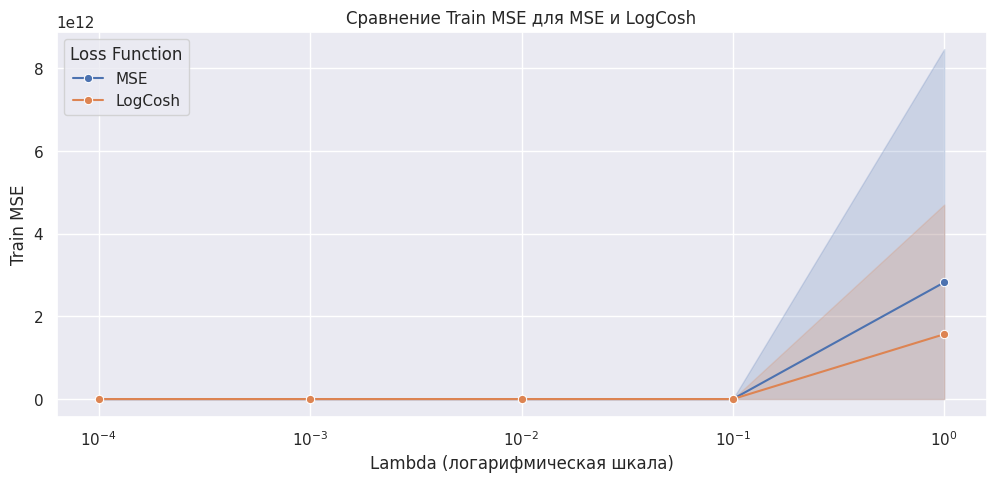

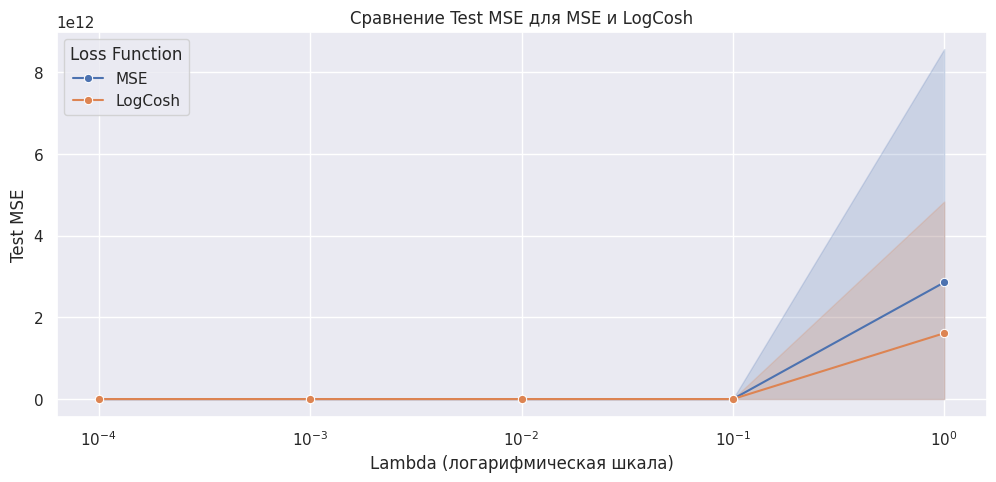

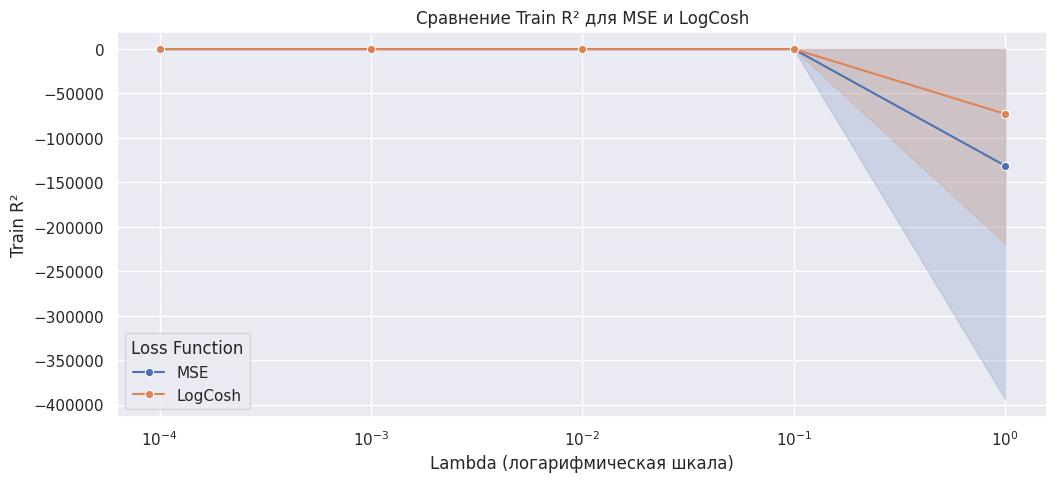

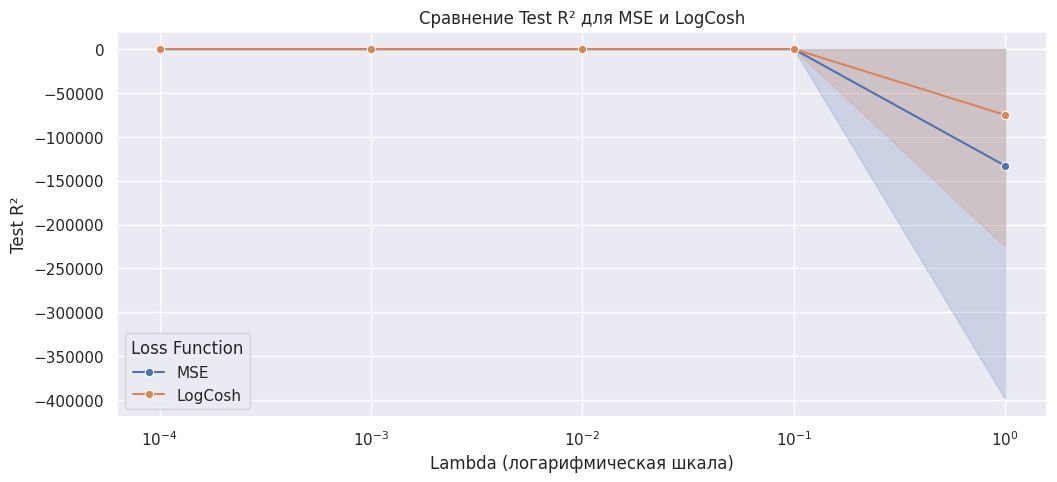

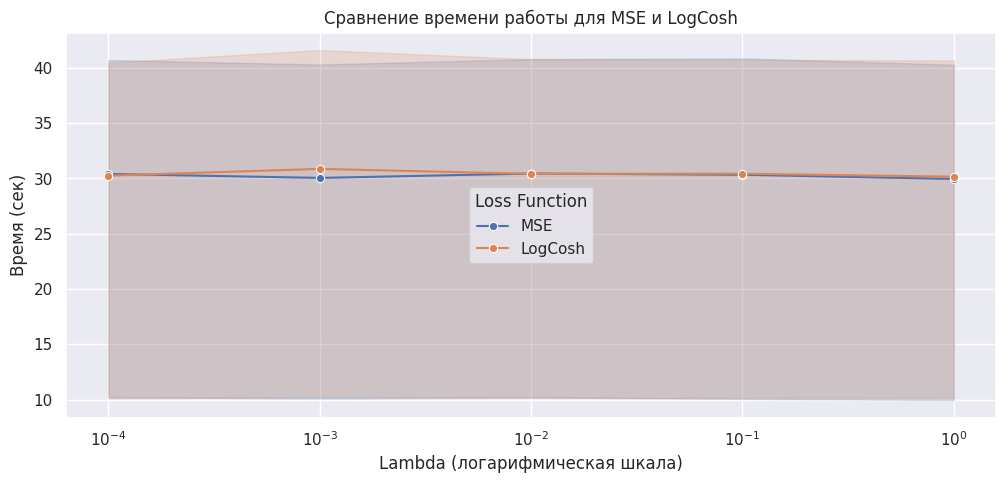

In [45]:
# График Train MSE
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_results, x="lambda", y="train_mse", hue="loss_function", marker="o")
plt.xscale("log")
plt.xlabel("Lambda (логарифмическая шкала)")
plt.ylabel("Train MSE")
plt.title("Сравнение Train MSE для MSE и LogCosh")
plt.legend(title="Loss Function")
plt.show()

# График Test MSE
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_results, x="lambda", y="test_mse", hue="loss_function", marker="o")
plt.xscale("log")
plt.xlabel("Lambda (логарифмическая шкала)")
plt.ylabel("Test MSE")
plt.title("Сравнение Test MSE для MSE и LogCosh")
plt.legend(title="Loss Function")
plt.show()

# График Train R²
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_results, x="lambda", y="train_r2", hue="loss_function", marker="o")
plt.xscale("log")
plt.xlabel("Lambda (логарифмическая шкала)")
plt.ylabel("Train R²")
plt.title("Сравнение Train R² для MSE и LogCosh")
plt.legend(title="Loss Function")
plt.show()

# График Test R²
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_results, x="lambda", y="test_r2", hue="loss_function", marker="o")
plt.xscale("log")
plt.xlabel("Lambda (логарифмическая шкала)")
plt.ylabel("Test R²")
plt.title("Сравнение Test R² для MSE и LogCosh")
plt.legend(title="Loss Function")
plt.show()

# График времени работы
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_results, x="lambda", y="time", hue="loss_function", marker="o")
plt.xscale("log")
plt.xlabel("Lambda (логарифмическая шкала)")
plt.ylabel("Время (сек)")
plt.title("Сравнение времени работы для MSE и LogCosh")
plt.legend(title="Loss Function")
plt.show()

MSE сильнее реагирует на выбросы в данных.  С ростом параметра Lambda её устойчивость улучшается, но слишком сильная регуляризация снижает качество модели. LogCosh проявляет большую устойчивость к шуму и выбросам, обеспечивая более плавную оптимизацию, особенно при малых значениях Lambda. Однако эта функция требует больше вычислительных ресурсов, что увеличивает время обучения.